# NB7: Combined Feature Analysis (Old + New Descriptors)

**Goal:** Merge best features from old nb6 (point-based) and new nb6 (plane-based),
define feature combinations ensuring proven features are included, and test each on:

| | Regression (LOO R2) | Classification (LOO F1, threshold 1.5) |
|---|---|---|
| **205 rows** | GroupLeaveOneOut by uid | GroupLeaveOneOut by uid |
| **99 rows** | Standard LOO | Standard LOO |

**Location:** `Keshav-DDP/k-path/old+new_nb6/nb7_combined_analysis.ipynb`

## Cell 1: Configuration

In [1]:
import os

# =============================================================================
# PATHS -- CHANGE THESE IF YOU MOVE THE NOTEBOOK
# =============================================================================
BASE_DIR = os.path.abspath(os.path.join("..", ".."))

# Old nb6 CSV (point-based descriptors, 205 rows)
OLD_CSV = os.path.join(
    BASE_DIR, "k-path", "old+new_nb6",
    "rashba_206_all_descriptors_old.csv"
)

# New nb6 CSV (plane-based descriptors, 205 rows)
NEW_CSV = os.path.join(
    BASE_DIR, "k-path", "old+new_nb6",
    "rashba_206_all_descriptors.csv"
)

RESULTS_DIR = os.path.join(".", "nb7_combined-results")
os.makedirs(RESULTS_DIR, exist_ok=True)

# =============================================================================
print("=" * 65)
print("  PATH CONFIGURATION")
print("=" * 65)
for name, path in [("BASE_DIR", BASE_DIR), ("OLD_CSV", OLD_CSV),
                    ("NEW_CSV", NEW_CSV), ("RESULTS_DIR", RESULTS_DIR)]:
    exists = os.path.exists(path)
    status = "OK" if exists else "MISSING"
    print(f"  [{status:7s}] {name:15s} = {path}")

  PATH CONFIGURATION
  [OK     ] BASE_DIR        = c:\Users\AbCMS_Lab\Desktop\Keshav-DDP
  [OK     ] OLD_CSV         = c:\Users\AbCMS_Lab\Desktop\Keshav-DDP\k-path\old+new_nb6\rashba_206_all_descriptors_old.csv
  [OK     ] NEW_CSV         = c:\Users\AbCMS_Lab\Desktop\Keshav-DDP\k-path\old+new_nb6\rashba_206_all_descriptors.csv
  [OK     ] RESULTS_DIR     = .\nb7_combined-results


## Cell 2: Imports

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from time import time
import seaborn as sns

from sklearn.model_selection import (
    LeaveOneOut, LeaveOneGroupOut, GroupKFold,
    cross_val_score, cross_val_predict
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import (
    r2_score, mean_absolute_error, f1_score, roc_auc_score,
    accuracy_score, precision_score, recall_score
)
from xgboost import XGBRegressor, XGBClassifier

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11})

print("Imports OK.")

Imports OK.


## Cell 3: Load and merge CSVs

In [3]:
df_old = pd.read_csv(OLD_CSV)
df_new = pd.read_csv(NEW_CSV)

print(f"Old CSV: {df_old.shape[0]} rows, {df_old.shape[1]} columns")
print(f"New CSV: {df_new.shape[0]} rows, {df_new.shape[1]} columns")

ID_COLS = ['Formula', 'uid', 'kpath', 'Rashba_parameter']
TARGET = 'Rashba_parameter'

# Merge: add all features from both, prefix overlapping names
df_merged = df_old[ID_COLS].copy()

old_features = [c for c in df_old.columns if c not in ID_COLS]
new_features = [c for c in df_new.columns if c not in ID_COLS]
overlap = set(old_features) & set(new_features)

print(f"Overlapping feature names: {len(overlap)}")

for col in old_features:
    new_name = f"old_{col}" if col in overlap else col
    df_merged[new_name] = df_old[col].values

for col in new_features:
    new_name = f"new_{col}" if col in overlap else col
    if new_name not in df_merged.columns:
        df_merged[new_name] = df_new[col].values

print(f"Merged: {df_merged.shape[0]} rows, {df_merged.shape[1]} columns")

Old CSV: 205 rows, 1263 columns
New CSV: 205 rows, 134 columns
Overlapping feature names: 27
Merged: 205 rows, 1393 columns


## Cell 4: Define feature combinations

**Proven important features from all stages:**
- E_pfrac_VBM, E_pfrac_CBM (DOS, Stage 1-2)
- radius_mean (+0.184 R2 boost, Stage 2)
- max_Z4 (Z^4 ~ SOC strength, best classification combo)
- max_Z (in best classification combo)
- pmid_afs_gauss_std (best new plane feature)
- pmid_grdf_trig_max (dominated new nb6 pairs)
- kpath_angle_deg (k-path geometry)
- ehull (stability, helped in new nb6)

In [4]:
all_cols = set(df_merged.columns)


def resolve_features(feat_list):
    """Resolve feature names: try original, then old_, then new_ prefix."""
    resolved = []
    missing = []
    for f in feat_list:
        if f in all_cols:
            resolved.append(f)
        elif f"old_{f}" in all_cols:
            resolved.append(f"old_{f}")
        elif f"new_{f}" in all_cols:
            resolved.append(f"new_{f}")
        else:
            missing.append(f)
    if missing:
        print(f"    WARNING missing: {missing}")
    return resolved


def swap_epfrac_for_99(features, df_cols):
    """
    For 99-row evaluation:
    - Replace E_pfrac_relevant -> E_pfrac_VBM + E_pfrac_CBM
    - Drop band_binary (meaningless for single-row-per-compound)
    """
    new_feats = []
    added_vbm_cbm = False

    for f in features:
        if 'E_pfrac_relevant' in f:
            if not added_vbm_cbm:
                for c in ['E_pfrac_VBM', 'old_E_pfrac_VBM', 'new_E_pfrac_VBM']:
                    if c in df_cols:
                        new_feats.append(c)
                        break
                for c in ['E_pfrac_CBM', 'old_E_pfrac_CBM', 'new_E_pfrac_CBM']:
                    if c in df_cols:
                        new_feats.append(c)
                        break
                added_vbm_cbm = True
        elif 'band_binary' in f:
            continue
        else:
            new_feats.append(f)
    return new_feats


# ============================================================
# COMBO DEFINITIONS
# ============================================================
# Ensuring radius_mean and max_Z4 are included in key combos

COMBOS = {
    # --- Small combos (3-4 features) ---
    "C1_stage2_original": [
        "E_pfrac_relevant", "radius_mean",
    ],  # Will become VBM + CBM + radius_mean on 99 rows (the 0.563 baseline)

    "C2_new_best4": [
        "E_pfrac_relevant", "ehull", "pmid_afs_gauss_std", "kpath_angle_deg",
    ],

    "C3_old_best4": [
        "E_pfrac_relevant", "start_adf_min", "start_adf_n_triplets", "mid_nearest_Z",
    ],

    # --- Medium combos (5-7 features, the sweet spot for 99 rows) ---
    "C4_new4_plus_rm": [
        "E_pfrac_relevant", "ehull", "pmid_afs_gauss_std", "kpath_angle_deg", "radius_mean",
    ],

    "C5_new4_rm_Z4": [
        "E_pfrac_relevant", "ehull", "pmid_afs_gauss_std", "kpath_angle_deg",
        "radius_mean", "max_Z4",
    ],

    "C6_proven_plus_new": [
        "E_pfrac_relevant", "radius_mean", "max_Z4",
        "pmid_afs_gauss_std", "kpath_angle_deg", "ehull",
    ],  # All proven features + top new features

    "C7_old_best7": [
        "E_pfrac_relevant", "mid_adf_n_triplets", "start_adf_min",
        "mid_nearest_Z", "start_adf_mean", "kpath_angle_deg", "mid_nearest_Z4",
    ],

    "C8_old7_plus_rm": [
        "E_pfrac_relevant", "mid_adf_n_triplets", "start_adf_min",
        "mid_nearest_Z", "start_adf_mean", "kpath_angle_deg", "mid_nearest_Z4",
        "radius_mean",
    ],

    "C9_new_best7": [
        "pmid_grdf_trig_max", "E_pfrac_relevant", "E_pfrac_CBM",
        "radius_mean", "pmid_grdf_gauss_std", "kstart_frac_x", "pmid_afs_trig_mean",
    ],

    # --- Larger combos (8-10 features) ---
    "C10_balanced_all_proven": [
        "E_pfrac_relevant", "radius_mean", "max_Z4", "max_Z",
        "pmid_afs_gauss_std", "pmid_grdf_trig_max", "kpath_angle_deg", "ehull",
    ],  # All proven + all best new

    "C11_full_mix": [
        "E_pfrac_relevant", "radius_mean", "max_Z4", "max_Z",
        "pmid_afs_gauss_std", "pmid_grdf_trig_max", "kpath_angle_deg", "ehull",
        "mid_nearest_Z", "pstart_afs_gauss_std",
    ],

    "C12_balanced_plus_band": [
        "E_pfrac_relevant", "radius_mean", "max_Z4",
        "pmid_afs_gauss_std", "pmid_grdf_trig_max", "kpath_angle_deg", "ehull",
        "band_binary",
    ],

    # --- Kitchen sink (12-15+) ---
    "C13_kitchen_sink": [
        "E_pfrac_relevant", "E_pfrac_CBM", "radius_mean", "max_Z4", "max_Z",
        "mid_adf_n_triplets", "start_adf_min", "mid_nearest_Z", "start_adf_mean",
        "mid_nearest_Z4", "pmid_grdf_trig_max", "ehull", "pmid_afs_gauss_std",
        "pstart_afs_gauss_std", "kpath_angle_deg",
    ],

    "C14_everything": [
        "E_pfrac_relevant", "E_pfrac_CBM", "radius_mean", "ehull",
        "max_Z4", "max_Z", "n_elements", "sum_Z4",
        "mid_nearest_Z", "mid_nearest_Z4",
        "kpath_angle_deg", "band_binary", "kstart_frac_y", "kend_frac_x", "kvec_z",
        "pmid_grdf_trig_max", "pend_grdf_trig_max", "pmid_afs_gauss_std",
        "pstart_afs_gauss_std", "pstart_afs_bessel_std", "pmid_grdf_gauss_std",
        "start_adf_min", "start_adf_mean", "mid_adf_n_triplets", "mid_adf_max",
    ],
}

# Resolve
print("Resolving feature names:\n")
RESOLVED_COMBOS = {}
for name, feats in COMBOS.items():
    resolved = resolve_features(feats)
    RESOLVED_COMBOS[name] = resolved
    feats_99 = swap_epfrac_for_99(resolved, set(df_merged.columns))
    print(f"  {name}: {len(resolved)} feat (205) / {len(feats_99)} feat (99)")

Resolving feature names:

  C1_stage2_original: 2 feat (205) / 3 feat (99)
  C2_new_best4: 4 feat (205) / 5 feat (99)
  C3_old_best4: 4 feat (205) / 5 feat (99)
  C4_new4_plus_rm: 5 feat (205) / 6 feat (99)
  C5_new4_rm_Z4: 6 feat (205) / 7 feat (99)
  C6_proven_plus_new: 6 feat (205) / 7 feat (99)
  C7_old_best7: 7 feat (205) / 8 feat (99)
  C8_old7_plus_rm: 8 feat (205) / 9 feat (99)
  C9_new_best7: 7 feat (205) / 8 feat (99)
  C10_balanced_all_proven: 8 feat (205) / 9 feat (99)
  C11_full_mix: 10 feat (205) / 11 feat (99)
  C12_balanced_plus_band: 8 feat (205) / 8 feat (99)
  C13_kitchen_sink: 15 feat (205) / 16 feat (99)
  C14_everything: 25 feat (205) / 25 feat (99)


## Cell 5: Prepare datasets

In [5]:
y_205 = df_merged[TARGET].values
groups_205 = df_merged['uid'].values

# 99-row: max alpha_R per uid
idx_99 = df_merged.groupby('uid')[TARGET].idxmax()
df_99 = df_merged.loc[idx_99].reset_index(drop=True)
y_99 = df_99[TARGET].values

THRESHOLD = 1.5
y_class_205 = (y_205 >= THRESHOLD).astype(int)
y_class_99 = (y_99 >= THRESHOLD).astype(int)

print(f"205 rows: {len(y_205)} rows, {len(np.unique(groups_205))} compounds")
print(f"99 rows:  {len(y_99)} rows")
print(f"Classification (t={THRESHOLD}): 205={y_class_205.sum()}+/{len(y_class_205)-y_class_205.sum()}-  "
      f"99={y_class_99.sum()}+/{len(y_class_99)-y_class_99.sum()}-")

205 rows: 205 rows, 99 compounds
99 rows:  99 rows
Classification (t=1.5): 205=89+/116-  99=50+/49-


## Cell 6: Model configs

In [6]:
XGB_REG_PARAMS = dict(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1.0, reg_lambda=1.0,
    random_state=42, verbosity=0
)

XGB_CLF_PARAMS = dict(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1.0, reg_lambda=1.0,
    scale_pos_weight=3,
    eval_metric='logloss', use_label_encoder=False,
    random_state=42, verbosity=0
)

## Cell 7: Evaluation functions

In [7]:
def eval_reg_205(features):
    X = df_merged[features].fillna(0).values
    model = XGBRegressor(**XGB_REG_PARAMS)
    y_pred = cross_val_predict(model, X, y_205, cv=LeaveOneGroupOut(), groups=groups_205)
    return r2_score(y_205, y_pred), mean_absolute_error(y_205, y_pred)

def eval_reg_99(features):
    feats_99 = swap_epfrac_for_99(features, set(df_99.columns))
    X = df_99[feats_99].fillna(0).values
    model = XGBRegressor(**XGB_REG_PARAMS)
    y_pred = cross_val_predict(model, X, y_99, cv=LeaveOneOut())
    return r2_score(y_99, y_pred), mean_absolute_error(y_99, y_pred), feats_99

def eval_clf_205(features):
    X = df_merged[features].fillna(0).values
    model = XGBClassifier(**XGB_CLF_PARAMS)
    logo = LeaveOneGroupOut()
    y_pred = cross_val_predict(model, X, y_class_205, cv=logo, groups=groups_205)
    try:
        y_prob = cross_val_predict(model, X, y_class_205, cv=logo, groups=groups_205, method='predict_proba')[:, 1]
        auc = roc_auc_score(y_class_205, y_prob)
    except:
        auc = np.nan
    return f1_score(y_class_205, y_pred), auc, precision_score(y_class_205, y_pred, zero_division=0), recall_score(y_class_205, y_pred, zero_division=0)

def eval_clf_99(features):
    feats_99 = swap_epfrac_for_99(features, set(df_99.columns))
    X = df_99[feats_99].fillna(0).values
    model = XGBClassifier(**XGB_CLF_PARAMS)
    y_pred = cross_val_predict(model, X, y_class_99, cv=LeaveOneOut())
    try:
        y_prob = cross_val_predict(model, X, y_class_99, cv=LeaveOneOut(), method='predict_proba')[:, 1]
        auc = roc_auc_score(y_class_99, y_prob)
    except:
        auc = np.nan
    return f1_score(y_class_99, y_pred), auc, precision_score(y_class_99, y_pred, zero_division=0), recall_score(y_class_99, y_pred, zero_division=0)

print("Evaluation functions defined.")

Evaluation functions defined.


## Cell 8: RUN ALL COMBOS x 4 SCENARIOS

In [8]:
print("=" * 80)
print(f"  RUNNING {len(RESOLVED_COMBOS)} COMBOS x 4 SCENARIOS")
print("=" * 80)

all_results = []

for combo_name, features in RESOLVED_COMBOS.items():
    if not features:
        continue

    print(f"\n  {combo_name} ({len(features)} feat)...", end=" ", flush=True)
    t0 = time()
    result = {'combo': combo_name, 'n_feat': len(features), 'features': ', '.join(features)}

    # 1. Regression 205
    try:
        r2, mae = eval_reg_205(features)
        result['reg205_r2'] = r2
        result['reg205_mae'] = mae
    except Exception as e:
        result['reg205_r2'] = np.nan; result['reg205_mae'] = np.nan

    # 2. Regression 99
    try:
        r2, mae, feats_99 = eval_reg_99(features)
        result['reg99_r2'] = r2
        result['reg99_mae'] = mae
        result['n_feat_99'] = len(feats_99)
        result['features_99'] = ', '.join(feats_99)
    except Exception as e:
        result['reg99_r2'] = np.nan; result['reg99_mae'] = np.nan

    # 3. Classification 205
    try:
        f1, auc, prec, rec = eval_clf_205(features)
        result['clf205_f1'] = f1; result['clf205_auc'] = auc
        result['clf205_prec'] = prec; result['clf205_rec'] = rec
    except:
        result['clf205_f1'] = np.nan; result['clf205_auc'] = np.nan

    # 4. Classification 99
    try:
        f1, auc, prec, rec = eval_clf_99(features)
        result['clf99_f1'] = f1; result['clf99_auc'] = auc
        result['clf99_prec'] = prec; result['clf99_rec'] = rec
    except:
        result['clf99_f1'] = np.nan; result['clf99_auc'] = np.nan

    elapsed = time() - t0
    print(f"R2_99={result.get('reg99_r2', np.nan):.4f}, F1_99={result.get('clf99_f1', np.nan):.4f} ({elapsed:.1f}s)")

    all_results.append(result)

results_df = pd.DataFrame(all_results)
results_df.to_csv(os.path.join(RESULTS_DIR, "all_results.csv"), index=False)

  RUNNING 14 COMBOS x 4 SCENARIOS

  C1_stage2_original (2 feat)... R2_99=0.5634, F1_99=0.8000 (15.6s)

  C2_new_best4 (4 feat)... R2_99=0.5778, F1_99=0.8000 (16.0s)

  C3_old_best4 (4 feat)... R2_99=0.5483, F1_99=0.7963 (14.6s)

  C4_new4_plus_rm (5 feat)... R2_99=0.5970, F1_99=0.8113 (14.7s)

  C5_new4_rm_Z4 (6 feat)... R2_99=0.5979, F1_99=0.8000 (14.5s)

  C6_proven_plus_new (6 feat)... R2_99=0.6320, F1_99=0.8073 (14.5s)

  C7_old_best7 (7 feat)... R2_99=0.5496, F1_99=0.8182 (15.0s)

  C8_old7_plus_rm (8 feat)... R2_99=0.5752, F1_99=0.7778 (17.7s)

  C9_new_best7 (7 feat)... R2_99=0.4878, F1_99=0.8598 (15.0s)

  C10_balanced_all_proven (8 feat)... R2_99=0.6021, F1_99=0.8148 (14.5s)

  C11_full_mix (10 feat)... R2_99=0.5549, F1_99=0.8333 (14.8s)

  C12_balanced_plus_band (8 feat)... R2_99=0.5590, F1_99=0.8411 (14.7s)

  C13_kitchen_sink (15 feat)... R2_99=0.5645, F1_99=0.7890 (15.4s)

  C14_everything (25 feat)... R2_99=0.5254, F1_99=0.8269 (16.5s)


## Cell 9: Summary tables

In [9]:
print("=" * 80)
print("  REGRESSION RESULTS (sorted by 99-row LOO R2)")
print("=" * 80)
reg_cols = ['combo', 'n_feat', 'n_feat_99', 'reg205_r2', 'reg99_r2', 'reg99_mae']
print(results_df[reg_cols].sort_values('reg99_r2', ascending=False).to_string(index=False))

print(f"\n{'='*80}")
print("  CLASSIFICATION RESULTS (sorted by 99-row LOO F1)")
print("=" * 80)
clf_cols = ['combo', 'n_feat', 'clf205_f1', 'clf205_auc', 'clf99_f1', 'clf99_auc', 'clf99_prec', 'clf99_rec']
print(results_df[clf_cols].sort_values('clf99_f1', ascending=False).to_string(index=False))

print(f"\nReference (previous best):")
print(f"  Regression 99:     R2 = 0.563 (3 feat)")
print(f"  Classification 99: F1 = 0.849, AUC = 0.907 (5 feat)")

  REGRESSION RESULTS (sorted by 99-row LOO R2)
                  combo  n_feat  n_feat_99  reg205_r2  reg99_r2  reg99_mae
     C6_proven_plus_new       6          7   0.461583  0.631983   0.428356
C10_balanced_all_proven       8          9   0.461486  0.602110   0.422795
          C5_new4_rm_Z4       6          7   0.474084  0.597947   0.438492
        C4_new4_plus_rm       5          6   0.471148  0.596975   0.452216
           C2_new_best4       4          5   0.511592  0.577831   0.452470
        C8_old7_plus_rm       8          9   0.430043  0.575163   0.459317
       C13_kitchen_sink      15         16   0.465063  0.564454   0.458230
     C1_stage2_original       2          3   0.118467  0.563368   0.478718
 C12_balanced_plus_band       8          8   0.515087  0.559009   0.463297
           C11_full_mix      10         11   0.462818  0.554927   0.459616
           C7_old_best7       7          8   0.449421  0.549584   0.467197
           C3_old_best4       4          5   0.435404

## Cell 10: Heatmap visualization

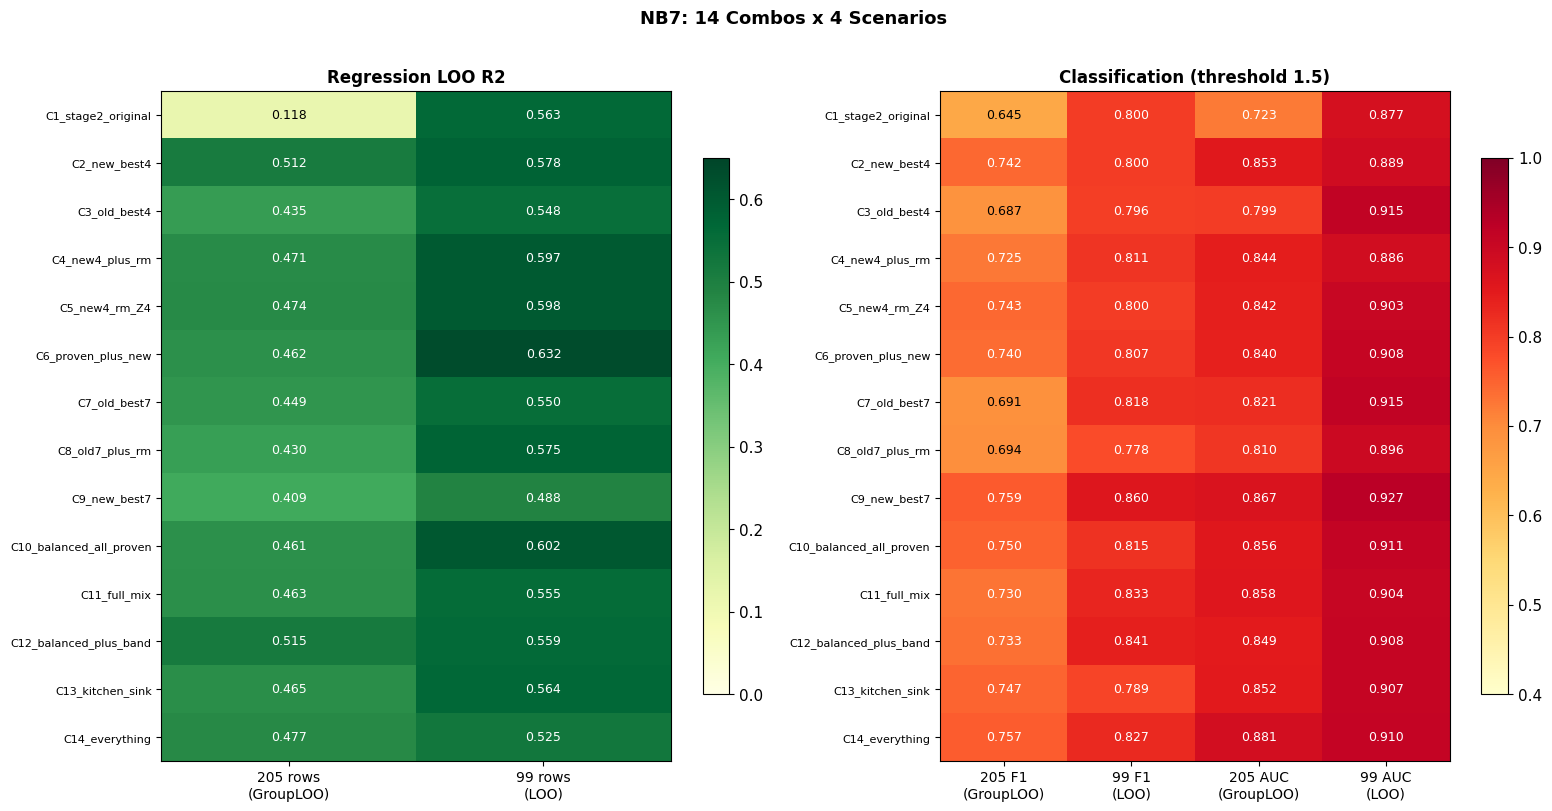

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, max(8, len(results_df) * 0.45)))

# Regression heatmap
reg_data = results_df[['combo', 'reg205_r2', 'reg99_r2']].set_index('combo')
reg_data.columns = ['205 rows\n(GroupLOO)', '99 rows\n(LOO)']

ax = axes[0]
im = ax.imshow(reg_data.values, cmap='YlGn', aspect='auto', vmin=0, vmax=0.65)
ax.set_xticks(range(len(reg_data.columns)))
ax.set_xticklabels(reg_data.columns, fontsize=10)
ax.set_yticks(range(len(reg_data.index)))
ax.set_yticklabels(reg_data.index, fontsize=8)
ax.set_title('Regression LOO R2', fontsize=12, fontweight='bold')
for i in range(len(reg_data.index)):
    for j in range(len(reg_data.columns)):
        val = reg_data.values[i, j]
        if not np.isnan(val):
            color = 'white' if val > 0.4 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9, color=color)
plt.colorbar(im, ax=ax, shrink=0.8)

# Classification heatmap
clf_data = results_df[['combo', 'clf205_f1', 'clf99_f1', 'clf205_auc', 'clf99_auc']].set_index('combo')
clf_data.columns = ['205 F1\n(GroupLOO)', '99 F1\n(LOO)', '205 AUC\n(GroupLOO)', '99 AUC\n(LOO)']

ax = axes[1]
im2 = ax.imshow(clf_data.values, cmap='YlOrRd', aspect='auto', vmin=0.4, vmax=1.0)
ax.set_xticks(range(len(clf_data.columns)))
ax.set_xticklabels(clf_data.columns, fontsize=10)
ax.set_yticks(range(len(clf_data.index)))
ax.set_yticklabels(clf_data.index, fontsize=8)
ax.set_title('Classification (threshold 1.5)', fontsize=12, fontweight='bold')
for i in range(len(clf_data.index)):
    for j in range(len(clf_data.columns)):
        val = clf_data.values[i, j]
        if not np.isnan(val):
            color = 'white' if val > 0.7 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9, color=color)
plt.colorbar(im2, ax=ax, shrink=0.8)

plt.suptitle(f'NB7: {len(results_df)} Combos x 4 Scenarios', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "heatmap_all.png"), dpi=150, bbox_inches='tight')
plt.show()

## Cell 11: Multi-model test on top 5 combos (99 rows)

In [11]:
MODELS = {
    'XGBoost': XGBRegressor(**XGB_REG_PARAMS),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    'GradBoosting': GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42),
    'SVR_RBF': Pipeline([('scaler', StandardScaler()), ('svr', SVR(kernel='rbf', C=10, gamma='scale'))]),
}

top5 = results_df.nlargest(5, 'reg99_r2')

print("=" * 80)
print("  MULTI-MODEL REGRESSION ON 99 ROWS (LOO)")
print("=" * 80)

multi_results = []

for _, row in top5.iterrows():
    name = row['combo']
    feats_205 = [f.strip() for f in row['features'].split(',')]
    feats_99 = swap_epfrac_for_99(feats_205, set(df_99.columns))

    missing = [f for f in feats_99 if f not in df_99.columns]
    if missing:
        print(f"\n  SKIP {name}: missing {missing}")
        continue

    X = df_99[feats_99].fillna(0).values
    print(f"\n  {name} ({len(feats_99)} feat):")

    for model_name, model in MODELS.items():
        try:
            y_pred = cross_val_predict(model, X, y_99, cv=LeaveOneOut())
            r2 = r2_score(y_99, y_pred)
            mae = mean_absolute_error(y_99, y_pred)
            multi_results.append({'combo': name, 'model': model_name, 'n_feat': len(feats_99),
                                  'loo_r2': r2, 'loo_mae': mae})
            print(f"    {model_name:15s}: R2={r2:.4f}, MAE={mae:.4f}")
        except Exception as e:
            print(f"    {model_name:15s}: ERROR {e}")

multi_df = pd.DataFrame(multi_results)
multi_df.to_csv(os.path.join(RESULTS_DIR, "multi_model_results.csv"), index=False)

print(f"\n  Best per combo:")
for name in top5['combo']:
    subset = multi_df[multi_df['combo'] == name]
    if len(subset) == 0:
        continue
    best = subset.loc[subset['loo_r2'].idxmax()]
    print(f"    {best['combo']:<30s} {best['model']:<15s} R2={best['loo_r2']:.4f}")

  MULTI-MODEL REGRESSION ON 99 ROWS (LOO)

  C6_proven_plus_new (7 feat):
    XGBoost        : R2=0.6320, MAE=0.4284
    RandomForest   : R2=0.5070, MAE=0.4901
    GradBoosting   : R2=0.5322, MAE=0.4607
    SVR_RBF        : R2=0.3618, MAE=0.5283

  C10_balanced_all_proven (9 feat):
    XGBoost        : R2=0.6021, MAE=0.4228
    RandomForest   : R2=0.4939, MAE=0.4908
    GradBoosting   : R2=0.5609, MAE=0.4532
    SVR_RBF        : R2=0.2957, MAE=0.5361

  C5_new4_rm_Z4 (7 feat):
    XGBoost        : R2=0.5979, MAE=0.4385
    RandomForest   : R2=0.5089, MAE=0.4886
    GradBoosting   : R2=0.5307, MAE=0.4615
    SVR_RBF        : R2=0.3618, MAE=0.5283

  C4_new4_plus_rm (6 feat):
    XGBoost        : R2=0.5970, MAE=0.4522
    RandomForest   : R2=0.5146, MAE=0.4866
    GradBoosting   : R2=0.5627, MAE=0.4517
    SVR_RBF        : R2=0.4275, MAE=0.4908

  C2_new_best4 (5 feat):
    XGBoost        : R2=0.5778, MAE=0.4525
    RandomForest   : R2=0.4962, MAE=0.4874
    GradBoosting   : R2=0.5499, M

## Cell 12: Feature correlation heatmap

  FEATURE CORRELATION HEATMAP


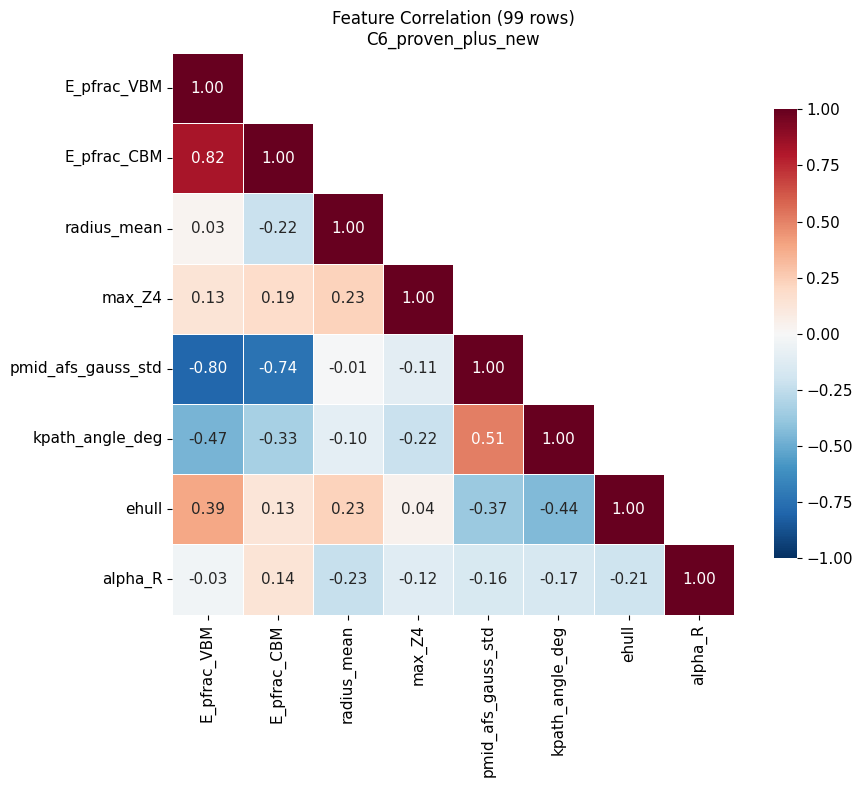

Correlation with alpha_R:
  radius_mean              : r = -0.228
  ehull                    : r = -0.208
  kpath_angle_deg          : r = -0.167
  pmid_afs_gauss_std       : r = -0.157
  E_pfrac_CBM              : r = +0.136
  max_Z4                   : r = -0.118
  E_pfrac_VBM              : r = -0.034


In [12]:
print("=" * 80)
print("  FEATURE CORRELATION HEATMAP")
print("=" * 80)

# Use features from the best 99-row combo
best_99 = results_df.loc[results_df['reg99_r2'].idxmax()]
best_feats_205 = [f.strip() for f in best_99['features'].split(',')]
best_feats_99 = swap_epfrac_for_99(best_feats_205, set(df_99.columns))

# Short names for display
def short_name(col):
    return col.replace('old_', '').replace('new_', '')

# 99-row correlation
avail_99 = [f for f in best_feats_99 if f in df_99.columns]
corr_data = df_99[avail_99 + [TARGET]].copy()
corr_data.columns = [short_name(c) for c in avail_99] + ['alpha_R']
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(corr_matrix)
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, mask=mask, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title(f'Feature Correlation (99 rows)\n{best_99["combo"]}', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "correlation_heatmap.png"), dpi=150, bbox_inches='tight')
plt.show()

print("Correlation with alpha_R:")
target_corr = corr_matrix['alpha_R'].drop('alpha_R').sort_values(key=abs, ascending=False)
for feat, corr in target_corr.items():
    print(f"  {feat:25s}: r = {corr:+.3f}")

## Cell 13: Predicted vs Actual (best combos)

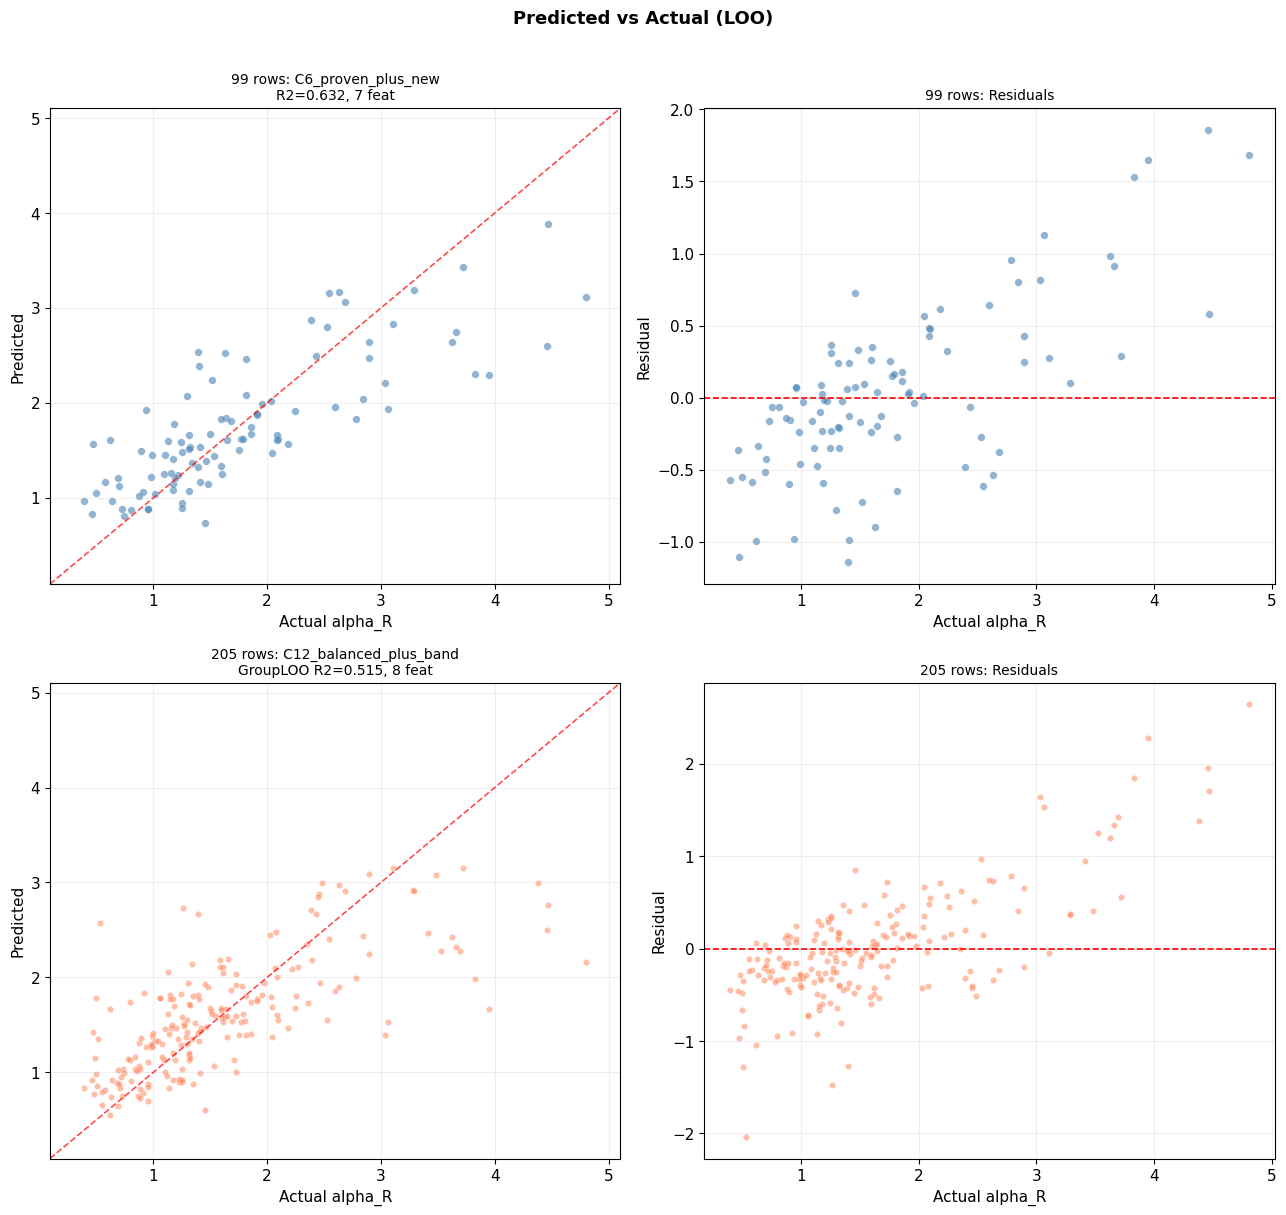

In [13]:
best_reg99 = results_df.loc[results_df['reg99_r2'].idxmax()]
best_reg205 = results_df.loc[results_df['reg205_r2'].idxmax()]

fig, axes = plt.subplots(2, 2, figsize=(13, 12))

# --- 99 rows best ---
feats_205 = [f.strip() for f in best_reg99['features'].split(',')]
feats_99 = swap_epfrac_for_99(feats_205, set(df_99.columns))
X = df_99[feats_99].fillna(0).values
model = XGBRegressor(**XGB_REG_PARAMS)
y_pred_99 = cross_val_predict(model, X, y_99, cv=LeaveOneOut())
r2_99_val = r2_score(y_99, y_pred_99)

ax = axes[0, 0]
ax.scatter(y_99, y_pred_99, alpha=0.6, s=30, color='steelblue', edgecolor='white', lw=0.3)
lims = [min(y_99.min(), y_pred_99.min()) - 0.3, max(y_99.max(), y_pred_99.max()) + 0.3]
ax.plot(lims, lims, 'r--', lw=1.2, alpha=0.7)
ax.set_xlabel('Actual alpha_R'); ax.set_ylabel('Predicted')
ax.set_title(f'99 rows: {best_reg99["combo"]}\nR2={r2_99_val:.3f}, {len(feats_99)} feat', fontsize=10)
ax.set_xlim(lims); ax.set_ylim(lims); ax.grid(True, alpha=0.2)

# 99 rows residuals
ax = axes[0, 1]
ax.scatter(y_99, y_99 - y_pred_99, alpha=0.6, s=30, color='steelblue', edgecolor='white', lw=0.3)
ax.axhline(y=0, color='red', linestyle='--', lw=1.2)
ax.set_xlabel('Actual alpha_R'); ax.set_ylabel('Residual')
ax.set_title('99 rows: Residuals', fontsize=10); ax.grid(True, alpha=0.2)

# --- 205 rows best ---
feats_205_b = [f.strip() for f in best_reg205['features'].split(',')]
X = df_merged[feats_205_b].fillna(0).values
model = XGBRegressor(**XGB_REG_PARAMS)
y_pred_205 = cross_val_predict(model, X, y_205, cv=LeaveOneGroupOut(), groups=groups_205)
r2_205_val = r2_score(y_205, y_pred_205)

ax = axes[1, 0]
ax.scatter(y_205, y_pred_205, alpha=0.5, s=20, color='coral', edgecolor='white', lw=0.3)
lims2 = [min(y_205.min(), y_pred_205.min()) - 0.3, max(y_205.max(), y_pred_205.max()) + 0.3]
ax.plot(lims2, lims2, 'r--', lw=1.2, alpha=0.7)
ax.set_xlabel('Actual alpha_R'); ax.set_ylabel('Predicted')
ax.set_title(f'205 rows: {best_reg205["combo"]}\nGroupLOO R2={r2_205_val:.3f}, {len(feats_205_b)} feat', fontsize=10)
ax.set_xlim(lims2); ax.set_ylim(lims2); ax.grid(True, alpha=0.2)

# 205 rows residuals
ax = axes[1, 1]
ax.scatter(y_205, y_205 - y_pred_205, alpha=0.5, s=20, color='coral', edgecolor='white', lw=0.3)
ax.axhline(y=0, color='red', linestyle='--', lw=1.2)
ax.set_xlabel('Actual alpha_R'); ax.set_ylabel('Residual')
ax.set_title('205 rows: Residuals', fontsize=10); ax.grid(True, alpha=0.2)

plt.suptitle('Predicted vs Actual (LOO)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "pred_vs_actual.png"), dpi=150, bbox_inches='tight')
plt.show()

## Cell 14: Feature importance for top 3 combos

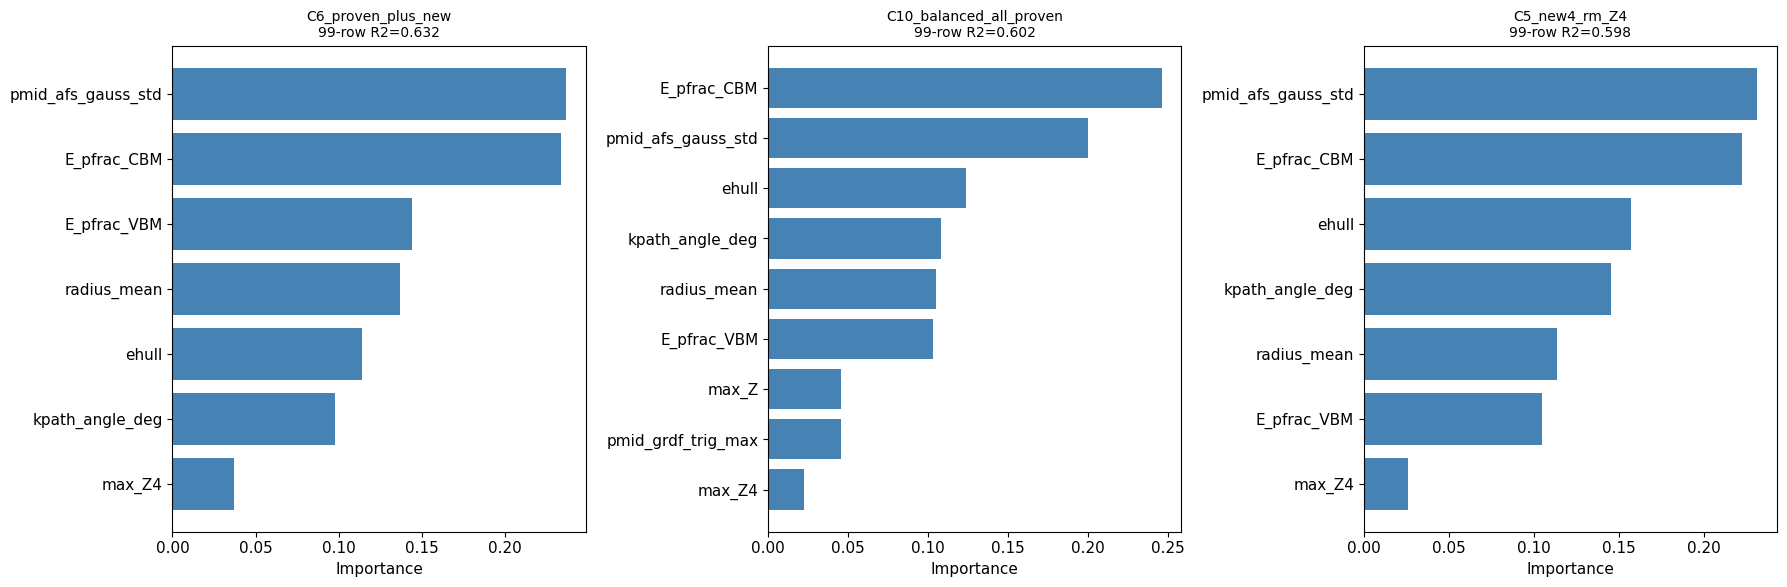

In [14]:
top3 = results_df.nlargest(3, 'reg99_r2')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (_, row) in enumerate(top3.iterrows()):
    feats_205 = [f.strip() for f in row['features'].split(',')]
    feats_99 = swap_epfrac_for_99(feats_205, set(df_99.columns))
    avail = [f for f in feats_99 if f in df_99.columns]

    X = df_99[avail].fillna(0).values
    model = XGBRegressor(**XGB_REG_PARAMS)
    model.fit(X, y_99)

    imp = model.feature_importances_
    labels = [short_name(f) for f in avail]
    imp_df = pd.DataFrame({'feature': labels, 'importance': imp}).sort_values('importance', ascending=True)

    ax = axes[idx]
    ax.barh(imp_df['feature'], imp_df['importance'], color='steelblue')
    ax.set_xlabel('Importance')
    ax.set_title(f"{row['combo']}\n99-row R2={row['reg99_r2']:.3f}", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "feature_importance_top3.png"), dpi=150, bbox_inches='tight')
plt.show()

## Cell 15: R2 / F1 vs feature count

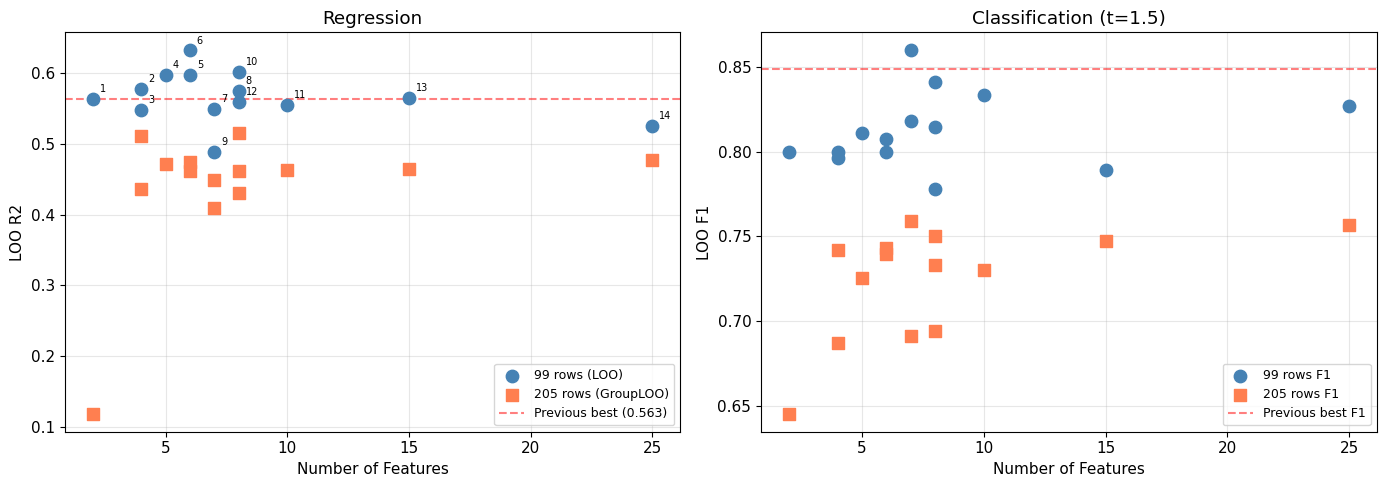

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(results_df['n_feat'], results_df['reg99_r2'], s=80, color='steelblue', label='99 rows (LOO)', zorder=3)
ax.scatter(results_df['n_feat'], results_df['reg205_r2'], s=80, color='coral', marker='s', label='205 rows (GroupLOO)', zorder=3)
ax.axhline(y=0.563, color='red', linestyle='--', alpha=0.5, label='Previous best (0.563)')
ax.set_xlabel('Number of Features'); ax.set_ylabel('LOO R2'); ax.set_title('Regression')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
for _, row in results_df.iterrows():
    ax.annotate(row['combo'].replace('C', '').split('_')[0], (row['n_feat'], row['reg99_r2']),
                textcoords="offset points", xytext=(5, 5), fontsize=7)

ax = axes[1]
ax.scatter(results_df['n_feat'], results_df['clf99_f1'], s=80, color='steelblue', label='99 rows F1', zorder=3)
ax.scatter(results_df['n_feat'], results_df['clf205_f1'], s=80, color='coral', marker='s', label='205 rows F1', zorder=3)
ax.axhline(y=0.849, color='red', linestyle='--', alpha=0.5, label='Previous best F1')
ax.set_xlabel('Number of Features'); ax.set_ylabel('LOO F1'); ax.set_title('Classification (t=1.5)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "scatter_nfeat.png"), dpi=150, bbox_inches='tight')
plt.show()

## Cell 16: Save CSVs

In [16]:
df_merged.to_csv(os.path.join(RESULTS_DIR, "merged_old_new_205.csv"), index=False)
df_99.to_csv(os.path.join(RESULTS_DIR, "merged_old_new_99.csv"), index=False)
print(f"Saved merged CSVs to {RESULTS_DIR}/")

Saved merged CSVs to .\nb7_combined-results/


## Cell 17: Final summary

In [17]:
print("=" * 80)
print("  NB7 COMPLETE -- FINAL SUMMARY")
print("=" * 80)

best_r99 = results_df.loc[results_df['reg99_r2'].idxmax()]
best_r205 = results_df.loc[results_df['reg205_r2'].idxmax()]
best_c99 = results_df.loc[results_df['clf99_f1'].idxmax()]
best_c205 = results_df.loc[results_df['clf205_f1'].idxmax()]

print(f"""
  {len(RESOLVED_COMBOS)} feature combos x 4 scenarios = {len(RESOLVED_COMBOS)*4} evaluations

  REGRESSION:
    99 rows (LOO):       {best_r99['combo']} -> R2 = {best_r99['reg99_r2']:.4f} ({int(best_r99.get('n_feat_99', best_r99['n_feat']))} feat)
    205 rows (GroupLOO):  {best_r205['combo']} -> R2 = {best_r205['reg205_r2']:.4f} ({best_r205['n_feat']} feat)
    Previous best:       R2 = 0.563 (3 feat)

  CLASSIFICATION (threshold 1.5):
    99 rows (LOO):       {best_c99['combo']} -> F1 = {best_c99['clf99_f1']:.4f}, AUC = {best_c99['clf99_auc']:.4f}
    205 rows (GroupLOO):  {best_c205['combo']} -> F1 = {best_c205['clf205_f1']:.4f}, AUC = {best_c205['clf205_auc']:.4f}
    Previous best:       F1 = 0.849, AUC = 0.907 (5 feat)

  KEY FEATURES:
    E_pfrac_VBM/CBM:     DOS p-orbital fraction at band edges (proven, Stages 1-2)
    radius_mean:          Mean atomic radius (+0.02 R2 boost consistently)
    max_Z4:               Z^4 of heaviest element (SOC coupling constant)
    pmid_afs_gauss_std:   Angular symmetry at midpoint k-plane (new, plane-based)
    pmid_grdf_trig_max:   Radial distribution at midpoint k-plane (new)
    kpath_angle_deg:      K-path direction in BZ (geometry)
    ehull:                Thermodynamic stability
""")

  NB7 COMPLETE -- FINAL SUMMARY

  14 feature combos x 4 scenarios = 56 evaluations

  REGRESSION:
    99 rows (LOO):       C6_proven_plus_new -> R2 = 0.6320 (7 feat)
    205 rows (GroupLOO):  C12_balanced_plus_band -> R2 = 0.5151 (8 feat)
    Previous best:       R2 = 0.563 (3 feat)

  CLASSIFICATION (threshold 1.5):
    99 rows (LOO):       C9_new_best7 -> F1 = 0.8598, AUC = 0.9269
    205 rows (GroupLOO):  C9_new_best7 -> F1 = 0.7590, AUC = 0.8670
    Previous best:       F1 = 0.849, AUC = 0.907 (5 feat)

  KEY FEATURES:
    E_pfrac_VBM/CBM:     DOS p-orbital fraction at band edges (proven, Stages 1-2)
    radius_mean:          Mean atomic radius (+0.02 R2 boost consistently)
    max_Z4:               Z^4 of heaviest element (SOC coupling constant)
    pmid_afs_gauss_std:   Angular symmetry at midpoint k-plane (new, plane-based)
    pmid_grdf_trig_max:   Radial distribution at midpoint k-plane (new)
    kpath_angle_deg:      K-path direction in BZ (geometry)
    ehull:              

  TWO-STAGE HURDLE MODEL (99 rows, LOO)

  C6_proven_plus_new (7 feat):
    Stage 1 classifier: F1=0.807, Acc=0.788
    Single-stage:  R2=0.6320, MAE=0.4284
    Two-stage:     R2=0.3637, MAE=0.5349  (delta=-0.2683)
    Strong class:  single R2=0.383 -> hurdle R2=0.020
    Weak class:    single R2=-1.361 -> hurdle R2=-3.796

  C5_new4_rm_Z4 (7 feat):
    Stage 1 classifier: F1=0.800, Acc=0.778
    Single-stage:  R2=0.5979, MAE=0.4385
    Two-stage:     R2=0.3553, MAE=0.5401  (delta=-0.2426)
    Strong class:  single R2=0.338 -> hurdle R2=0.028
    Weak class:    single R2=-1.682 -> hurdle R2=-4.033

  C10_balanced_all (9 feat):
    Stage 1 classifier: F1=0.815, Acc=0.798
    Single-stage:  R2=0.6021, MAE=0.4228
    Two-stage:     R2=0.3883, MAE=0.5250  (delta=-0.2138)
    Strong class:  single R2=0.354 -> hurdle R2=0.050
    Weak class:    single R2=-1.727 -> hurdle R2=-3.549

  HURDLE MODEL SUMMARY

  Combo                     #feat  Single R2  Hurdle R2    Delta
  --------------------

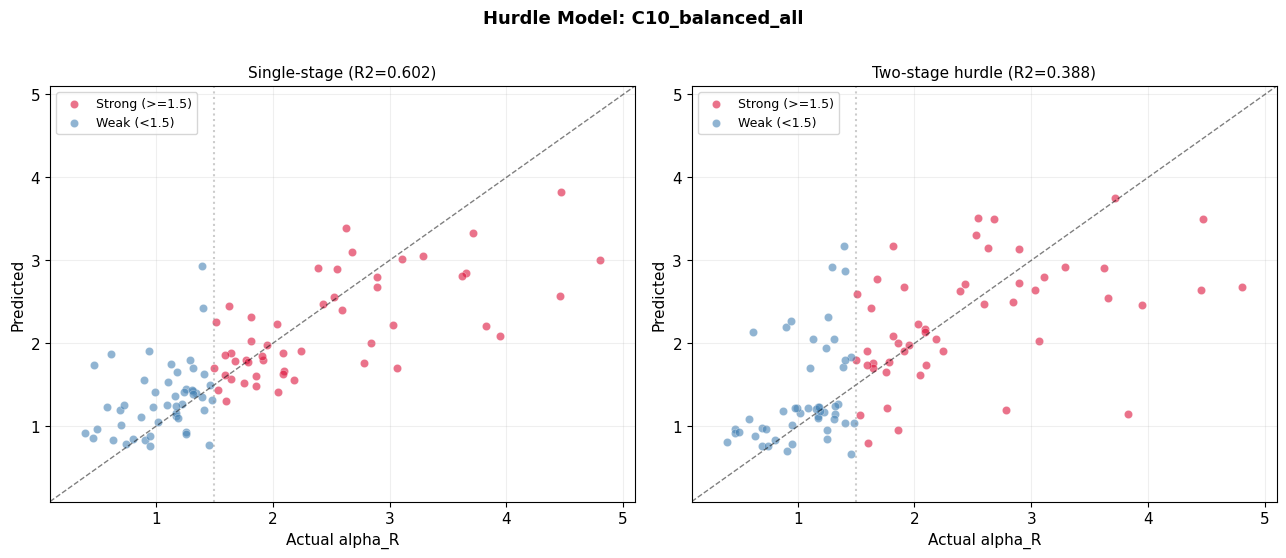

In [18]:
# %% [markdown]
# ## Cell 18: Two-Stage Hurdle Model
#
# Stage 1: Classify strong (>=1.5) vs weak (<1.5) Rashba
# Stage 2: Train separate XGBoost regressors for each class
# Evaluate end-to-end with LOO on 99 rows.

# %%
print("=" * 80)
print("  TWO-STAGE HURDLE MODEL (99 rows, LOO)")
print("=" * 80)

# Combos to test (top 3 from regression + the best classifier combo)
HURDLE_COMBOS = {
    "C6_proven_plus_new": resolve_features([
        "E_pfrac_relevant", "radius_mean", "max_Z4",
        "pmid_afs_gauss_std", "kpath_angle_deg", "ehull",
    ]),
    "C5_new4_rm_Z4": resolve_features([
        "E_pfrac_relevant", "ehull", "pmid_afs_gauss_std", "kpath_angle_deg",
        "radius_mean", "max_Z4",
    ]),
    "C10_balanced_all": resolve_features([
        "E_pfrac_relevant", "radius_mean", "max_Z4", "max_Z",
        "pmid_afs_gauss_std", "pmid_grdf_trig_max", "kpath_angle_deg", "ehull",
    ]),
}

THRESHOLD = 1.5
hurdle_results = []

for combo_name, feats_205 in HURDLE_COMBOS.items():
    feats_99 = swap_epfrac_for_99(feats_205, set(df_99.columns))
    missing = [f for f in feats_99 if f not in df_99.columns]
    if missing:
        print(f"\n  SKIP {combo_name}: missing {missing}")
        continue

    X = df_99[feats_99].fillna(0).values
    y_true = y_99.copy()
    y_class_true = (y_true >= THRESHOLD).astype(int)

    n = len(y_true)
    y_pred_hurdle = np.zeros(n)
    y_pred_class = np.zeros(n, dtype=int)
    y_pred_single = np.zeros(n)  # single-stage regression for comparison

    for i in range(n):
        # LOO split
        X_train = np.delete(X, i, axis=0)
        y_train = np.delete(y_true, i)
        y_class_train = np.delete(y_class_true, i)
        X_test = X[i:i+1]

        # --- Single-stage regression (baseline) ---
        reg_single = XGBRegressor(**XGB_REG_PARAMS)
        reg_single.fit(X_train, y_train)
        y_pred_single[i] = reg_single.predict(X_test)[0]

        # --- Stage 1: Classification ---
        clf = XGBClassifier(**XGB_CLF_PARAMS)
        clf.fit(X_train, y_class_train)
        pred_class = clf.predict(X_test)[0]
        y_pred_class[i] = pred_class

        # --- Stage 2: Class-specific regression ---
        if pred_class == 1:  # predicted strong
            mask = y_class_train == 1
        else:  # predicted weak
            mask = y_class_train == 0

        X_class = X_train[mask]
        y_class_reg = y_train[mask]

        if len(X_class) < 5:
            # Too few samples in class, fall back to full regression
            reg = XGBRegressor(**XGB_REG_PARAMS)
            reg.fit(X_train, y_train)
        else:
            reg = XGBRegressor(**XGB_REG_PARAMS)
            reg.fit(X_class, y_class_reg)

        y_pred_hurdle[i] = reg.predict(X_test)[0]

    # Metrics
    r2_hurdle = r2_score(y_true, y_pred_hurdle)
    mae_hurdle = mean_absolute_error(y_true, y_pred_hurdle)
    r2_single = r2_score(y_true, y_pred_single)
    mae_single = mean_absolute_error(y_true, y_pred_single)
    clf_acc = accuracy_score(y_class_true, y_pred_class)
    clf_f1 = f1_score(y_class_true, y_pred_class)

    # R2 within each class
    strong_mask = y_class_true == 1
    weak_mask = y_class_true == 0

    r2_strong_hurdle = r2_score(y_true[strong_mask], y_pred_hurdle[strong_mask]) if strong_mask.sum() > 2 else np.nan
    r2_weak_hurdle = r2_score(y_true[weak_mask], y_pred_hurdle[weak_mask]) if weak_mask.sum() > 2 else np.nan
    r2_strong_single = r2_score(y_true[strong_mask], y_pred_single[strong_mask]) if strong_mask.sum() > 2 else np.nan
    r2_weak_single = r2_score(y_true[weak_mask], y_pred_single[weak_mask]) if weak_mask.sum() > 2 else np.nan

    hurdle_results.append({
        'combo': combo_name, 'n_feat': len(feats_99),
        'r2_single': r2_single, 'r2_hurdle': r2_hurdle,
        'mae_single': mae_single, 'mae_hurdle': mae_hurdle,
        'clf_f1': clf_f1, 'clf_acc': clf_acc,
        'r2_strong_single': r2_strong_single, 'r2_strong_hurdle': r2_strong_hurdle,
        'r2_weak_single': r2_weak_single, 'r2_weak_hurdle': r2_weak_hurdle,
    })

    delta_r2 = r2_hurdle - r2_single
    print(f"\n  {combo_name} ({len(feats_99)} feat):")
    print(f"    Stage 1 classifier: F1={clf_f1:.3f}, Acc={clf_acc:.3f}")
    print(f"    Single-stage:  R2={r2_single:.4f}, MAE={mae_single:.4f}")
    print(f"    Two-stage:     R2={r2_hurdle:.4f}, MAE={mae_hurdle:.4f}  (delta={delta_r2:+.4f})")
    print(f"    Strong class:  single R2={r2_strong_single:.3f} -> hurdle R2={r2_strong_hurdle:.3f}")
    print(f"    Weak class:    single R2={r2_weak_single:.3f} -> hurdle R2={r2_weak_hurdle:.3f}")

# Summary
print(f"\n{'='*80}")
print("  HURDLE MODEL SUMMARY")
print(f"{'='*80}")
print(f"\n  {'Combo':<25s} {'#feat':>5s} {'Single R2':>10s} {'Hurdle R2':>10s} {'Delta':>8s}")
print(f"  {'-'*62}")
for r in hurdle_results:
    delta = r['r2_hurdle'] - r['r2_single']
    print(f"  {r['combo']:<25s} {r['n_feat']:>5d} {r['r2_single']:>10.4f} {r['r2_hurdle']:>10.4f} {delta:>+8.4f}")

# Plot: pred vs actual for best combo (both single and hurdle)
best_h = max(hurdle_results, key=lambda x: x['r2_hurdle'])
best_name = best_h['combo']
feats_205 = HURDLE_COMBOS[best_name]
feats_99 = swap_epfrac_for_99(feats_205, set(df_99.columns))
X = df_99[feats_99].fillna(0).values

# Recompute predictions for plotting
y_pred_s = np.zeros(len(y_99))
y_pred_h = np.zeros(len(y_99))
for i in range(len(y_99)):
    X_tr = np.delete(X, i, axis=0)
    y_tr = np.delete(y_99, i)
    yc_tr = np.delete(y_class_99, i)
    X_te = X[i:i+1]

    reg_s = XGBRegressor(**XGB_REG_PARAMS)
    reg_s.fit(X_tr, y_tr)
    y_pred_s[i] = reg_s.predict(X_te)[0]

    clf = XGBClassifier(**XGB_CLF_PARAMS)
    clf.fit(X_tr, yc_tr)
    pc = clf.predict(X_te)[0]
    mask = yc_tr == pc
    X_c = X_tr[mask]; y_c = y_tr[mask]
    if len(X_c) < 5:
        reg_h = XGBRegressor(**XGB_REG_PARAMS)
        reg_h.fit(X_tr, y_tr)
    else:
        reg_h = XGBRegressor(**XGB_REG_PARAMS)
        reg_h.fit(X_c, y_c)
    y_pred_h[i] = reg_h.predict(X_te)[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for idx, (label, y_p, r2_val) in enumerate([
    (f"Single-stage (R2={r2_score(y_99, y_pred_s):.3f})", y_pred_s, r2_score(y_99, y_pred_s)),
    (f"Two-stage hurdle (R2={r2_score(y_99, y_pred_h):.3f})", y_pred_h, r2_score(y_99, y_pred_h)),
]):
    ax = axes[idx]
    strong = y_class_99 == 1
    ax.scatter(y_99[strong], y_p[strong], alpha=0.6, s=35, color='crimson', label='Strong (>=1.5)', edgecolor='white', lw=0.3)
    ax.scatter(y_99[~strong], y_p[~strong], alpha=0.6, s=35, color='steelblue', label='Weak (<1.5)', edgecolor='white', lw=0.3)
    lims = [min(y_99.min(), y_p.min()) - 0.3, max(y_99.max(), y_p.max()) + 0.3]
    ax.plot(lims, lims, 'k--', lw=1, alpha=0.5)
    ax.axvline(x=1.5, color='gray', linestyle=':', alpha=0.4)
    ax.set_xlabel('Actual alpha_R'); ax.set_ylabel('Predicted')
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=9); ax.set_xlim(lims); ax.set_ylim(lims); ax.grid(True, alpha=0.2)

plt.suptitle(f'Hurdle Model: {best_name}', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "hurdle_model.png"), dpi=150, bbox_inches='tight')
plt.show()

hurdle_df = pd.DataFrame(hurdle_results)
hurdle_df.to_csv(os.path.join(RESULTS_DIR, "hurdle_results.csv"), index=False)

In [20]:
# %% [markdown]
# ## Cell 19: Test ALL Combos + S/D Orbital Fractions
#
# Load s/d fractions from nb1.5, merge with 99-row data,
# test every combo with and without d/s orbital additions.

# %%
# =============================================================================
# PATH TO nb1.5 OUTPUT -- UPDATE THIS
# =============================================================================
SD_FRAC_CSV = os.path.join(
    BASE_DIR, "Weight-contribution", "contribution-model",
    "nb1.5_sd_fraction-results", "sd_orbital_fractions.csv"
)

print("=" * 80)
print("  TESTING ALL COMBOS + S/D ORBITAL FRACTIONS (99 rows, LOO)")
print("=" * 80)

if not os.path.exists(SD_FRAC_CSV):
    print(f"ERROR: {SD_FRAC_CSV} not found. Run nb1.5 first.")
else:
    df_sd = pd.read_csv(SD_FRAC_CSV)
    print(f"Loaded s/d fractions: {df_sd.shape[0]} compounds")

    # Merge with 99-row data
    df_99_sd = df_99.merge(df_sd[['uid', 'E_sfrac_VBM', 'E_sfrac_CBM',
                                    'E_dfrac_VBM', 'E_dfrac_CBM']],
                            on='uid', how='left')

    print(f"  d-frac stats: VBM mean={df_99_sd['E_dfrac_VBM'].mean():.3f}, "
          f"CBM mean={df_99_sd['E_dfrac_CBM'].mean():.3f}")
    print(f"  Compounds with d-frac > 0.1: {(df_99_sd['E_dfrac_VBM'] > 0.1).sum()}/99")

    # Orbital additions to test
    ORBITAL_ADDITIONS = {
        "none": [],
        "+dfrac": ['E_dfrac_VBM', 'E_dfrac_CBM'],
        "+sfrac": ['E_sfrac_VBM', 'E_sfrac_CBM'],
        "+sd_all": ['E_sfrac_VBM', 'E_sfrac_CBM', 'E_dfrac_VBM', 'E_dfrac_CBM'],
    }

    sd_results = []

    for combo_name, feats_205 in RESOLVED_COMBOS.items():
        if not feats_205:
            continue

        feats_99 = swap_epfrac_for_99(feats_205, set(df_99_sd.columns))
        missing = [f for f in feats_99 if f not in df_99_sd.columns]
        if missing:
            print(f"\n  SKIP {combo_name}: missing {missing}")
            continue

        print(f"\n  {combo_name} ({len(feats_99)} base feat):", end="")

        for add_name, add_feats in ORBITAL_ADDITIONS.items():
            avail_add = [f for f in add_feats if f in df_99_sd.columns]
            combo_feats = feats_99 + avail_add

            X = df_99_sd[combo_feats].fillna(0).values
            model = XGBRegressor(**XGB_REG_PARAMS)
            y_pred = cross_val_predict(model, X, y_99, cv=LeaveOneOut())
            r2 = r2_score(y_99, y_pred)
            mae = mean_absolute_error(y_99, y_pred)

            sd_results.append({
                'combo': combo_name, 'addition': add_name,
                'n_feat': len(combo_feats), 'loo_r2': r2, 'loo_mae': mae,
            })

            if add_name == "none":
                base_r2 = r2
                print(f" base={r2:.4f}", end="")
            else:
                delta = r2 - base_r2
                marker = " ***" if delta > 0.01 else ""
                print(f" {add_name}={r2:.4f}({delta:+.3f}){marker}", end="")

        print()

    sd_df = pd.DataFrame(sd_results)
    sd_df.to_csv(os.path.join(RESULTS_DIR, "sd_orbital_results.csv"), index=False)

    # Summary: which additions helped most?
    print(f"\n{'='*80}")
    print("  SUMMARY: BEST ADDITION PER COMBO")
    print(f"{'='*80}")
    print(f"\n  {'Combo':<30s} {'Base R2':>8s} {'Best Add':>10s} {'New R2':>8s} {'Delta':>8s}")
    print(f"  {'-'*68}")

    for combo_name in RESOLVED_COMBOS.keys():
        subset = sd_df[sd_df['combo'] == combo_name]
        if len(subset) == 0:
            continue
        base = subset[subset['addition'] == 'none']['loo_r2'].values
        if len(base) == 0:
            continue
        base_r2 = base[0]
        best = subset.loc[subset['loo_r2'].idxmax()]
        delta = best['loo_r2'] - base_r2
        marker = " <-- IMPROVED" if delta > 0.005 else ""
        print(f"  {combo_name:<30s} {base_r2:>8.4f} {best['addition']:>10s} {best['loo_r2']:>8.4f} {delta:>+8.4f}{marker}")

    # Overall best
    best_overall = sd_df.loc[sd_df['loo_r2'].idxmax()]
    print(f"\n  OVERALL BEST: {best_overall['combo']} {best_overall['addition']} "
          f"-> R2={best_overall['loo_r2']:.4f} ({int(best_overall['n_feat'])} feat)")

    # Classification for top 5
    print(f"\n{'='*80}")
    print("  CLASSIFICATION WITH ORBITAL ADDITIONS (99-row, threshold 1.5)")
    print(f"{'='*80}")

    top5_reg = sd_df.nlargest(5, 'loo_r2')

    for _, row in top5_reg.iterrows():
        combo_name = row['combo']
        add_name = row['addition']

        feats_205 = RESOLVED_COMBOS[combo_name]
        feats_99 = swap_epfrac_for_99(feats_205, set(df_99_sd.columns))

        add_feats = ORBITAL_ADDITIONS.get(add_name, [])
        avail_add = [f for f in add_feats if f in df_99_sd.columns]
        combo_feats = feats_99 + avail_add

        X = df_99_sd[combo_feats].fillna(0).values
        model = XGBClassifier(**XGB_CLF_PARAMS)
        y_pred = cross_val_predict(model, X, y_class_99, cv=LeaveOneOut())
        try:
            y_prob = cross_val_predict(model, X, y_class_99, cv=LeaveOneOut(),
                                       method='predict_proba')[:, 1]
            auc = roc_auc_score(y_class_99, y_prob)
        except:
            auc = np.nan
        f1 = f1_score(y_class_99, y_pred)
        print(f"  {combo_name} {add_name}: F1={f1:.4f}, AUC={auc:.4f}, "
              f"R2={row['loo_r2']:.4f} ({int(row['n_feat'])} feat)")

  TESTING ALL COMBOS + S/D ORBITAL FRACTIONS (99 rows, LOO)
Loaded s/d fractions: 99 compounds
  d-frac stats: VBM mean=0.272, CBM mean=0.384
  Compounds with d-frac > 0.1: 45/99

  C1_stage2_original (3 base feat): base=0.5634 +dfrac=0.5083(-0.055) +sfrac=0.5338(-0.030) +sd_all=0.5121(-0.051)

  C2_new_best4 (5 base feat): base=0.5778 +dfrac=0.5878(+0.010) +sfrac=0.6152(+0.037) *** +sd_all=0.6058(+0.028) ***

  C3_old_best4 (5 base feat): base=0.5483 +dfrac=0.4865(-0.062) +sfrac=0.6152(+0.067) *** +sd_all=0.5731(+0.025) ***

  C4_new4_plus_rm (6 base feat): base=0.5970 +dfrac=0.5805(-0.017) +sfrac=0.6061(+0.009) +sd_all=0.5953(-0.002)

  C5_new4_rm_Z4 (7 base feat): base=0.5979 +dfrac=0.5980(+0.000) +sfrac=0.5938(-0.004) +sd_all=0.5660(-0.032)

  C6_proven_plus_new (7 base feat): base=0.6320 +dfrac=0.5982(-0.034) +sfrac=0.5896(-0.042) +sd_all=0.6024(-0.030)

  C7_old_best7 (8 base feat): base=0.5496 +dfrac=0.5036(-0.046) +sfrac=0.6227(+0.073) *** +sd_all=0.5840(+0.034) ***

  C8_old7_

In [21]:
# C6 + sfrac test
c6_feats = swap_epfrac_for_99(RESOLVED_COMBOS["C6_proven_plus_new"], set(df_99_sd.columns))
c6_sfrac = c6_feats + ['E_sfrac_VBM', 'E_sfrac_CBM']

X = df_99_sd[c6_sfrac].fillna(0).values
model = XGBRegressor(**XGB_REG_PARAMS)
y_pred = cross_val_predict(model, X, y_99, cv=LeaveOneOut())
r2 = r2_score(y_99, y_pred)
print(f"C6 + sfrac: R2={r2:.4f} ({len(c6_sfrac)} feat)")
print(f"C6 baseline: R2=0.6320 (7 feat)")
print(f"Delta: {r2 - 0.632:+.4f}")
print(f"Features: {c6_sfrac}")

C6 + sfrac: R2=0.5896 (9 feat)
C6 baseline: R2=0.6320 (7 feat)
Delta: -0.0424
Features: ['old_E_pfrac_VBM', 'old_E_pfrac_CBM', 'old_radius_mean', 'old_max_Z4', 'pmid_afs_gauss_std', 'old_kpath_angle_deg', 'old_ehull', 'E_sfrac_VBM', 'E_sfrac_CBM']


Features found: 23 + target


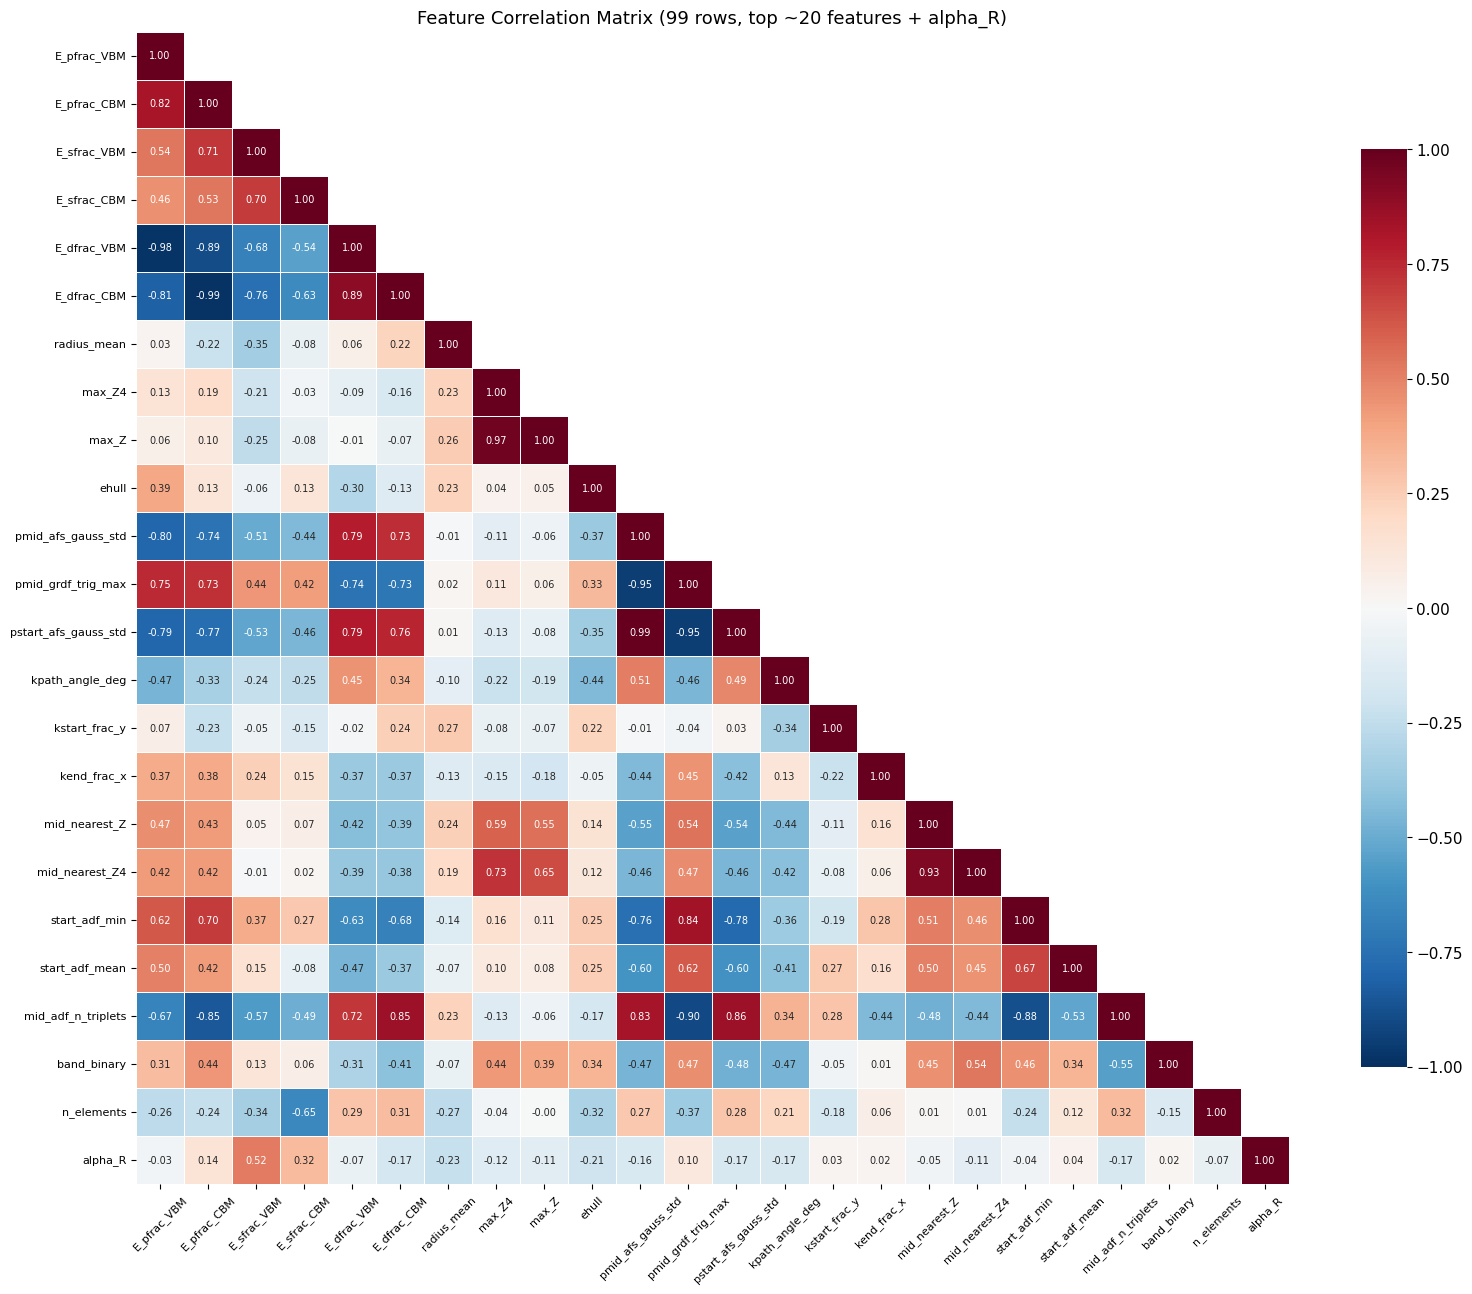


Correlation with alpha_R (sorted by |r|):

  E_sfrac_VBM              : r = +0.520  ++++++++++
  E_sfrac_CBM              : r = +0.319  ++++++
  radius_mean              : r = -0.228  ++++
  ehull                    : r = -0.208  ++++
  E_dfrac_CBM              : r = -0.173  +++
  pstart_afs_gauss_std     : r = -0.170  +++
  mid_adf_n_triplets       : r = -0.168  +++
  kpath_angle_deg          : r = -0.167  +++
  pmid_afs_gauss_std       : r = -0.157  +++
  E_pfrac_CBM              : r = +0.136  ++
  max_Z4                   : r = -0.118  ++
  max_Z                    : r = -0.110  ++
  mid_nearest_Z4           : r = -0.107  ++
  pmid_grdf_trig_max       : r = +0.105  ++
  n_elements               : r = -0.073  +
  E_dfrac_VBM              : r = -0.066  +
  mid_nearest_Z            : r = -0.045  
  start_adf_mean           : r = +0.044  
  start_adf_min            : r = -0.041  
  E_pfrac_VBM              : r = -0.034  
  kstart_frac_y            : r = +0.030  
  kend_frac_x          

In [22]:
# %% [markdown]
# ## Cell 20: Correlation Heatmap -- Top Features

# %%
import seaborn as sns

# All important features from our analysis
TOP_FEATURES_RAW = [
    # DOS (proven)
    'E_pfrac_VBM', 'E_pfrac_CBM', 'E_sfrac_VBM', 'E_sfrac_CBM', 'E_dfrac_VBM', 'E_dfrac_CBM',
    # Elemental (proven)
    'radius_mean', 'max_Z4', 'max_Z', 'ehull',
    # Plane-based (new)
    'pmid_afs_gauss_std', 'pmid_grdf_trig_max', 'pstart_afs_gauss_std',
    # K-path geometry
    'kpath_angle_deg', 'kstart_frac_y', 'kend_frac_x',
    # Old point-based
    'mid_nearest_Z', 'mid_nearest_Z4', 'start_adf_min', 'start_adf_mean',
    'mid_adf_n_triplets',
    # Other
    'band_binary', 'n_elements',
]

# Resolve names in df_99_sd
def find_col(name, df):
    if name in df.columns:
        return name
    if f"old_{name}" in df.columns:
        return f"old_{name}"
    if f"new_{name}" in df.columns:
        return f"new_{name}"
    return None

resolved = []
short_labels = []
for f in TOP_FEATURES_RAW:
    col = find_col(f, df_99_sd)
    if col is not None:
        resolved.append(col)
        short_labels.append(f)  # use clean name for display

# Add target
resolved.append('Rashba_parameter')
short_labels.append('alpha_R')

print(f"Features found: {len(resolved) - 1} + target")

# Compute correlation
corr_data = df_99_sd[resolved].copy()
corr_data.columns = short_labels
corr_matrix = corr_data.corr()

# Full heatmap
fig, ax = plt.subplots(figsize=(16, 14))
mask = np.zeros_like(corr_matrix)
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, mask=mask, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.7},
            annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix (99 rows, top ~20 features + alpha_R)', fontsize=13)
ax.tick_params(axis='x', labelsize=8, rotation=45)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "correlation_heatmap_top20.png"), dpi=150, bbox_inches='tight')
plt.show()

# Correlation with target
print("\nCorrelation with alpha_R (sorted by |r|):\n")
target_corr = corr_matrix['alpha_R'].drop('alpha_R').sort_values(key=abs, ascending=False)
for feat, corr in target_corr.items():
    bar = "+" * int(abs(corr) * 20)
    print(f"  {feat:25s}: r = {corr:+.3f}  {bar}")

# Highlight highly correlated pairs (|r| > 0.7, excluding target)
print("\n\nHighly correlated feature pairs (|r| > 0.7):\n")
feat_names = [s for s in short_labels if s != 'alpha_R']
found_pairs = False
for i, f1 in enumerate(feat_names):
    for f2 in feat_names[i+1:]:
        r = corr_matrix.loc[f1, f2]
        if abs(r) > 0.7:
            print(f"  {f1:25s} <-> {f2:25s}: r = {r:+.3f}  {'REDUNDANT' if abs(r) > 0.9 else 'HIGH'}")
            found_pairs = True
if not found_pairs:
    print("  None found (all |r| < 0.7)")

# Show which features in C6 (the winner) are correlated with each other
print("\n\nC6 internal correlations:")
c6_names = ['E_pfrac_VBM', 'E_pfrac_CBM', 'radius_mean', 'max_Z4',
            'pmid_afs_gauss_std', 'kpath_angle_deg', 'ehull']
c6_avail = [f for f in c6_names if f in corr_matrix.columns]
if c6_avail:
    c6_corr = corr_matrix.loc[c6_avail, c6_avail]
    print(c6_corr.to_string())

Feature pool (9):
  E_pfrac_VBM
  E_pfrac_CBM
  radius_mean
  max_Z4
  pmid_afs_gauss_std
  kpath_angle_deg
  ehull
  E_sfrac_VBM
  E_sfrac_CBM

  Total subsets: 511

  EXHAUSTIVE SUB-COMBINATIONS (9 features, 511 total)

  1-feature combos: 9 -> Best: R2=0.2540 -> ['E_sfrac_VBM']

  2-feature combos: 36 -> Best: R2=0.3828 -> ['E_pfrac_CBM', 'pmid_afs_gauss_std']

  3-feature combos: 84 -> Best: R2=0.5634 -> ['E_pfrac_VBM', 'E_pfrac_CBM', 'radius_mean']

  4-feature combos: 126 -> Best: R2=0.5906 -> ['E_pfrac_VBM', 'pmid_afs_gauss_std', 'kpath_angle_deg', 'E_sfrac_CBM']

  5-feature combos: 126 -> Best: R2=0.6188 -> ['E_pfrac_VBM', 'E_pfrac_CBM', 'radius_mean', 'pmid_afs_gauss_std', 'kpath_angle_deg']

  6-feature combos: 84 -> Best: R2=0.6434 -> ['E_pfrac_VBM', 'E_pfrac_CBM', 'radius_mean', 'pmid_afs_gauss_std', 'kpath_angle_deg', 'ehull']

  7-feature combos: 36 -> Best: R2=0.6320 -> ['E_pfrac_VBM', 'E_pfrac_CBM', 'radius_mean', 'max_Z4', 'pmid_afs_gauss_std', 'kpath_angle_deg', 'ehu

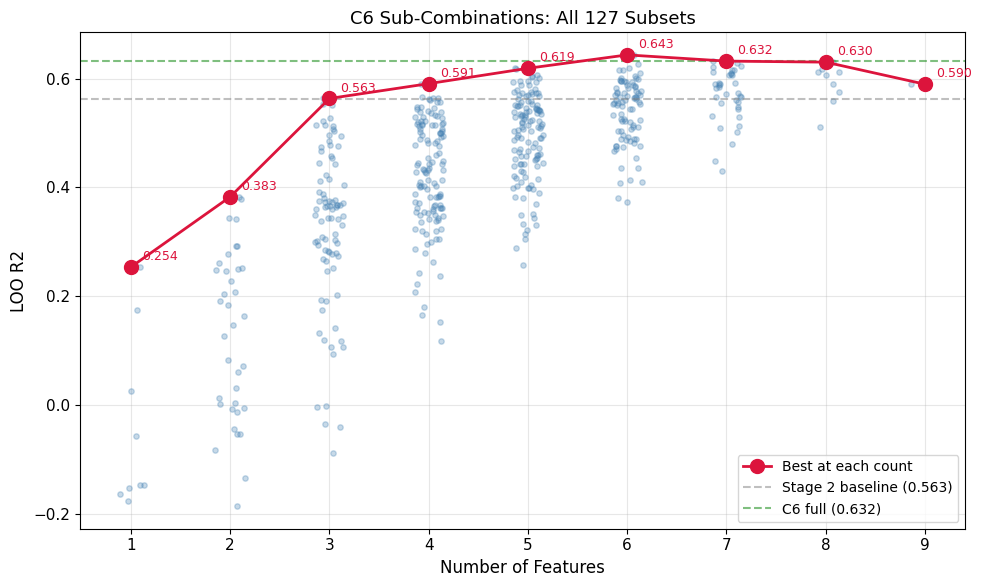


  CLASSIFICATION (threshold 1.5) FOR BEST AT EACH COUNT

  1 feat: R2=0.2540, F1=0.6557, AUC=0.6739  E_sfrac_VBM
  2 feat: R2=0.3828, F1=0.7273, AUC=0.8180  E_pfrac_CBM, pmid_afs_gauss_std
  3 feat: R2=0.5634, F1=0.8000, AUC=0.8767  E_pfrac_VBM, E_pfrac_CBM, radius_mean
  4 feat: R2=0.5906, F1=0.8545, AUC=0.8816  E_pfrac_VBM, pmid_afs_gauss_std, kpath_angle_deg, E_sfrac_CBM
  5 feat: R2=0.6188, F1=0.8113, AUC=0.8845  E_pfrac_VBM, E_pfrac_CBM, radius_mean, pmid_afs_gauss_std, kpath_angle_deg
  6 feat: R2=0.6434, F1=0.8113, AUC=0.8963  E_pfrac_VBM, E_pfrac_CBM, radius_mean, pmid_afs_gauss_std, kpath_angle_deg, ehull
  7 feat: R2=0.6320, F1=0.8073, AUC=0.9082  E_pfrac_VBM, E_pfrac_CBM, radius_mean, max_Z4, pmid_afs_gauss_std, kpath_angle_deg, ehull
  8 feat: R2=0.6301, F1=0.8257, AUC=0.9020  E_pfrac_VBM, E_pfrac_CBM, radius_mean, max_Z4, pmid_afs_gauss_std, kpath_angle_deg, ehull, E_sfrac_VBM
  9 feat: R2=0.5896, F1=0.8440, AUC=0.9000  E_pfrac_VBM, E_pfrac_CBM, radius_mean, max_Z4, pmid_

In [24]:
# %% [markdown]
# ## Cell 21: Exhaustive Sub-Combinations of Top Combo (C6)
#
# C6 has 7 features. Test ALL possible subsets: all 1s, all 2s, all 3s, etc.
# 7C1 + 7C2 + 7C3 + 7C4 + 7C5 + 7C6 + 7C7 = 7+21+35+35+21+7+1 = 127 combos.

# %%
from itertools import combinations

# C6 features + s-fraction (99-row version)
C6_FEATS = swap_epfrac_for_99(RESOLVED_COMBOS["C6_proven_plus_new"], set(df_99_sd.columns))

# Add s-fraction
POOL_FEATS = C6_FEATS.copy()
for sf in ['E_sfrac_VBM', 'E_sfrac_CBM']:
    if sf in df_99_sd.columns and sf not in POOL_FEATS:
        POOL_FEATS.append(sf)

# Verify all exist
missing = [f for f in POOL_FEATS if f not in df_99_sd.columns]
if missing:
    print(f"WARNING: missing {missing}")
else:
    print(f"Feature pool ({len(POOL_FEATS)}):")
    short = {f: f.replace('old_', '').replace('new_', '') for f in POOL_FEATS}
    for f in POOL_FEATS:
        print(f"  {short[f]}")

n_total = sum(len(list(combinations(range(len(POOL_FEATS)), k))) for k in range(1, len(POOL_FEATS)+1))
print(f"\n  Total subsets: {n_total}")

# Use df_99_sd instead of df_99 (has sfrac columns)
df_eval = df_99_sd

print(f"\n{'='*80}")
print(f"  EXHAUSTIVE SUB-COMBINATIONS ({len(POOL_FEATS)} features, {n_total} total)")
print(f"{'='*80}")

sub_results = []

for n in range(1, len(POOL_FEATS) + 1):
    combos = list(combinations(range(len(POOL_FEATS)), n))
    print(f"\n  {n}-feature combos: {len(combos)}", end="", flush=True)

    best_r2 = -999
    best_feats = None

    for combo_idx in combos:
        feats = [POOL_FEATS[i] for i in combo_idx]
        X = df_eval[feats].fillna(0).values
        model = XGBRegressor(**XGB_REG_PARAMS)
        y_pred = cross_val_predict(model, X, y_99, cv=LeaveOneOut())
        r2 = r2_score(y_99, y_pred)
        mae = mean_absolute_error(y_99, y_pred)

        sub_results.append({
            'n_feat': n,
            'features': ', '.join([short[f] for f in feats]),
            'features_full': ', '.join(feats),
            'loo_r2': r2,
            'loo_mae': mae,
        })

        if r2 > best_r2:
            best_r2 = r2
            best_feats = [short[f] for f in feats]

    print(f" -> Best: R2={best_r2:.4f} -> {best_feats}")

sub_df = pd.DataFrame(sub_results)
sub_df.to_csv(os.path.join(RESULTS_DIR, "c6_subcombos.csv"), index=False)

# Summary: best at each feature count
print(f"\n{'='*80}")
print(f"  BEST R2 AT EACH FEATURE COUNT")
print(f"{'='*80}\n")

best_per_n = []
for n in range(1, len(POOL_FEATS) + 1):
    subset = sub_df[sub_df['n_feat'] == n]
    best = subset.loc[subset['loo_r2'].idxmax()]
    best_per_n.append(best)
    print(f"  {n} feat: R2={best['loo_r2']:.4f}  {best['features']}")

# Also show top 3 at each count
print(f"\n{'='*80}")
print(f"  TOP 3 AT EACH FEATURE COUNT")
print(f"{'='*80}")

for n in range(1, len(POOL_FEATS) + 1):
    subset = sub_df[sub_df['n_feat'] == n].nlargest(3, 'loo_r2')
    print(f"\n  --- {n} features ---")
    for _, row in subset.iterrows():
        print(f"    R2={row['loo_r2']:.4f}  {row['features']}")

# Plot: R2 vs feature count (all combos as scatter, best as line)
fig, ax = plt.subplots(figsize=(10, 6))

# All combos as light dots
ax.scatter(sub_df['n_feat'] + np.random.uniform(-0.15, 0.15, len(sub_df)),
           sub_df['loo_r2'], alpha=0.3, s=15, color='steelblue', zorder=2)

# Best per n as connected line
best_ns = [b['n_feat'] for b in best_per_n]
best_r2s = [b['loo_r2'] for b in best_per_n]
ax.plot(best_ns, best_r2s, 'o-', color='crimson', lw=2, markersize=10, zorder=3, label='Best at each count')

# Reference lines
ax.axhline(y=0.563, color='gray', linestyle='--', alpha=0.5, label='Stage 2 baseline (0.563)')
ax.axhline(y=0.632, color='green', linestyle='--', alpha=0.5, label='C6 full (0.632)')

for b in best_per_n:
    ax.annotate(f"{b['loo_r2']:.3f}", (b['n_feat'], b['loo_r2']),
                textcoords="offset points", xytext=(8, 5), fontsize=9, color='crimson')

ax.set_xlabel('Number of Features', fontsize=12)
ax.set_ylabel('LOO R2', fontsize=12)
ax.set_title('C6 Sub-Combinations: All 127 Subsets', fontsize=13)
ax.set_xticks(range(1, len(POOL_FEATS) + 1))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "c6_subcombos_scatter.png"), dpi=150, bbox_inches='tight')
plt.show()

# Classification for best at each feature count
print(f"\n{'='*80}")
print(f"  CLASSIFICATION (threshold 1.5) FOR BEST AT EACH COUNT")
print(f"{'='*80}\n")

for b in best_per_n:
    feats = [f.strip() for f in b['features_full'].split(',')]
    X = df_eval[feats].fillna(0).values
    model = XGBClassifier(**XGB_CLF_PARAMS)
    y_pred = cross_val_predict(model, X, y_class_99, cv=LeaveOneOut())
    try:
        y_prob = cross_val_predict(model, X, y_class_99, cv=LeaveOneOut(), method='predict_proba')[:, 1]
        auc = roc_auc_score(y_class_99, y_prob)
    except:
        auc = np.nan
    f1 = f1_score(y_class_99, y_pred)
    print(f"  {int(b['n_feat'])} feat: R2={b['loo_r2']:.4f}, F1={f1:.4f}, AUC={auc:.4f}  {b['features']}")

## Cell 18: Multi-Model + Hyperparameter Tuning + Stacked Ensemble (Top 3 Combos)

In [29]:
from sklearn.linear_model import LinearRegression
from itertools import combinations

print("=" * 80)
print("  S-FRACTION FEATURE COMBINATION TESTING + STACKED MODELS")
print("=" * 80)

# =============================================================================
# STEP 1: LOAD S/D ORBITAL FRACTIONS
# =============================================================================
SD_FRAC_CSV = os.path.join(BASE_DIR, "Weight-contribution", "contribution-model",
                           "nb1.5_sd_fraction-results", "sd_orbital_fractions.csv")

if not os.path.exists(SD_FRAC_CSV):
    print(f"\nERROR: {SD_FRAC_CSV} not found. Run nb1.5 first.")
    raise FileNotFoundError("S-fraction CSV required for this analysis")

df_sd = pd.read_csv(SD_FRAC_CSV)
df_99_sd = df_99.merge(df_sd[['uid', 'E_sfrac_VBM', 'E_sfrac_CBM']], on='uid', how='left')

print(f"\nLoaded S-fractions: {df_99_sd.shape}")
print(f"  VBM correlation: {df_99_sd[['E_sfrac_VBM', TARGET]].corr().iloc[0,1]:.3f}")
print(f"  CBM correlation: {df_99_sd[['E_sfrac_CBM', TARGET]].corr().iloc[0,1]:.3f}")

# =============================================================================
# STEP 2: GET C6_PROVEN_PLUS_NEW FEATURES + S-FRACTIONS
# =============================================================================
c6_combo_name = "C6_proven_plus_new"
c6_feats_205 = [f.strip() for f in results_df[results_df['combo'] == c6_combo_name]['features'].values[0].split(',')]
c6_feats_99 = swap_epfrac_for_99(c6_feats_205, set(df_99_sd.columns))
c6_with_sfrac = c6_feats_99 + ['E_sfrac_VBM', 'E_sfrac_CBM']

print(f"\n{c6_combo_name} base features ({len(c6_feats_99)}):")
for f in c6_feats_99:
    print(f"  - {f}")
print(f"\nWith S-fractions ({len(c6_with_sfrac)}): {c6_with_sfrac}")

# =============================================================================
# STEP 3: TEST ALL C(n,5) AND C(n,6) COMBINATIONS
# =============================================================================
print(f"\n{'='*80}")
print(f"  TESTING ALL 5-FEATURE AND 6-FEATURE COMBINATIONS")
print(f"  Models: LinearRegression, SVR_RBF (no hyperparameter tuning)")
print(f"{'='*80}")

models = {
    'LR': Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())]),
    'SVR_RBF': Pipeline([('scaler', StandardScaler()), ('svr', SVR(kernel='rbf', C=10, gamma='scale'))])
}

combo_results = []

# Test 5-feature combinations
n_combos_5 = len(list(combinations(c6_with_sfrac, 5)))
print(f"\nTesting C({len(c6_with_sfrac)}, 5) = {n_combos_5} combinations...")
for idx, feat_combo in enumerate(combinations(c6_with_sfrac, 5), 1):
    if idx % 20 == 0:
        print(f"  Progress: {idx}/{n_combos_5}", end='\r', flush=True)
    
    feat_list = list(feat_combo)
    X = df_99_sd[feat_list].fillna(0).values
    
    for model_name, model in models.items():
        y_pred = cross_val_predict(model, X, y_99, cv=LeaveOneOut())
        r2 = r2_score(y_99, y_pred)
        mae = mean_absolute_error(y_99, y_pred)
        
        combo_results.append({
            'n_features': 5,
            'features': feat_list,
            'features_str': ', '.join(feat_list),
            'model': model_name,
            'loo_r2': r2,
            'loo_mae': mae
        })

print(f"\n  Completed 5-feature combinations")

# Test 6-feature combinations
n_combos_6 = len(list(combinations(c6_with_sfrac, 6)))
print(f"\nTesting C({len(c6_with_sfrac)}, 6) = {n_combos_6} combinations...")
for idx, feat_combo in enumerate(combinations(c6_with_sfrac, 6), 1):
    if idx % 20 == 0:
        print(f"  Progress: {idx}/{n_combos_6}", end='\r', flush=True)
    
    feat_list = list(feat_combo)
    X = df_99_sd[feat_list].fillna(0).values
    
    for model_name, model in models.items():
        y_pred = cross_val_predict(model, X, y_99, cv=LeaveOneOut())
        r2 = r2_score(y_99, y_pred)
        mae = mean_absolute_error(y_99, y_pred)
        
        combo_results.append({
            'n_features': 6,
            'features': feat_list,
            'features_str': ', '.join(feat_list),
            'model': model_name,
            'loo_r2': r2,
            'loo_mae': mae
        })

print(f"\n  Completed 6-feature combinations")

combo_df = pd.DataFrame(combo_results)
combo_df.to_csv(os.path.join(RESULTS_DIR, "sfrac_feature_combinations.csv"), index=False)

print(f"\n{'='*80}")
print(f"  TOP 10 FEATURE COMBINATIONS PER MODEL")
print(f"{'='*80}")

for model_name in ['LR', 'SVR_RBF']:
    print(f"\n{model_name} Top 10:")
    print(f"{'-'*80}")
    top10_model = combo_df[combo_df['model'] == model_name].nlargest(10, 'loo_r2')
    for idx, (_, row) in enumerate(top10_model.iterrows(), 1):
        print(f"{idx:2d}. {row['n_features']} feat | R2={row['loo_r2']:.4f}, MAE={row['loo_mae']:.4f}")
        print(f"    {row['features_str']}")

# =============================================================================
# STEP 4: STACKED MODELS ON TOP COMBINATIONS
# =============================================================================
print(f"\n\n{'='*80}")
print(f"  STACKED MODELS (LinReg/SVR → XGB)")
print(f"  Testing top 2 combos from EACH model (LR and SVR)")
print(f"{'='*80}")

# Get top 2 from each model
top2_lr = combo_df[combo_df['model'] == 'LR'].nlargest(2, 'loo_r2')
top2_svr = combo_df[combo_df['model'] == 'SVR_RBF'].nlargest(2, 'loo_r2')
top_combos_per_model = pd.concat([top2_lr, top2_svr])

stacked_results = []

for idx, row in top_combos_per_model.iterrows():
    feat_list = row['features']
    base_model_name = row['model']
    
    print(f"\n{'-'*80}")
    print(f"BASE: {base_model_name} | {row['n_features']} features | R2={row['loo_r2']:.4f}")
    print(f"Features: {row['features_str']}")
    print(f"{'-'*80}")
    
    # Get base features (without S-fractions)
    base_feats = [f for f in feat_list if f not in ['E_sfrac_VBM', 'E_sfrac_CBM']]
    
    # Test BOTH LR and SVR as Level 1 models
    for level1_name in ['LR', 'SVR_RBF']:
        level1_model = models[level1_name]
        
        # ------------------------------------------------------------------------
        # Approach 1: Level1 uses all features → XGB
        # ------------------------------------------------------------------------
        print(f"\n  [{level1_name}→XGB] All {len(feat_list)} features")
        
        X_all = df_99_sd[feat_list].fillna(0).values
        
        # Get Level 1 predictions
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_all)
        level1_preds = cross_val_predict(level1_model, X_scaled, y_99, cv=LeaveOneOut())
        
        # Level 2: XGB with original features + Level1 prediction
        X_stacked = np.column_stack([X_all, level1_preds])
        xgb_model = XGBRegressor(**XGB_REG_PARAMS)
        y_pred_stacked = cross_val_predict(xgb_model, X_stacked, y_99, cv=LeaveOneOut())
        
        r2_stacked = r2_score(y_99, y_pred_stacked)
        mae_stacked = mean_absolute_error(y_99, y_pred_stacked)
        
        print(f"    R2={r2_stacked:.4f}, MAE={mae_stacked:.4f} (Δ={r2_stacked-row['loo_r2']:+.4f})")
        
        stacked_results.append({
            'base_combo': row['features_str'],
            'base_model': base_model_name,
            'base_r2': row['loo_r2'],
            'approach': 'Full_features',
            'level1_model': level1_name,
            'level1_features': feat_list,
            'n_level1_feat': len(feat_list),
            'loo_r2': r2_stacked,
            'loo_mae': mae_stacked,
            'improvement': r2_stacked - row['loo_r2']
        })
        
        # ------------------------------------------------------------------------
        # Approach 2: Level1 uses ONLY S-fractions → XGB with base features
        # ------------------------------------------------------------------------
        if len(base_feats) > 0:
            print(f"  [{level1_name}→XGB] S-frac only → XGB + {len(base_feats)} base")
            
            X_sfrac = df_99_sd[['E_sfrac_VBM', 'E_sfrac_CBM']].fillna(0).values
            X_base = df_99_sd[base_feats].fillna(0).values
            
            # Get Level 1 predictions from S-fractions only
            scaler_sfrac = StandardScaler()
            X_sfrac_scaled = scaler_sfrac.fit_transform(X_sfrac)
            level1_preds_sfrac = cross_val_predict(level1_model, X_sfrac_scaled, y_99, cv=LeaveOneOut())
            
            # Level 2: XGB with base features + S-frac prediction
            X_stacked_sfrac = np.column_stack([X_base, level1_preds_sfrac])
            y_pred_stacked_sfrac = cross_val_predict(xgb_model, X_stacked_sfrac, y_99, cv=LeaveOneOut())
            
            r2_stacked_sfrac = r2_score(y_99, y_pred_stacked_sfrac)
            mae_stacked_sfrac = mean_absolute_error(y_99, y_pred_stacked_sfrac)
            
            print(f"    R2={r2_stacked_sfrac:.4f}, MAE={mae_stacked_sfrac:.4f} (Δ={r2_stacked_sfrac-row['loo_r2']:+.4f})")
            
            stacked_results.append({
                'base_combo': row['features_str'],
                'base_model': base_model_name,
                'base_r2': row['loo_r2'],
                'approach': 'Sfrac_only',
                'level1_model': level1_name,
                'level1_features': ['E_sfrac_VBM', 'E_sfrac_CBM'],
                'n_level1_feat': 2,
                'loo_r2': r2_stacked_sfrac,
                'loo_mae': mae_stacked_sfrac,
                'improvement': r2_stacked_sfrac - row['loo_r2']
            })

stacked_df = pd.DataFrame(stacked_results)
stacked_df.to_csv(os.path.join(RESULTS_DIR, "stacked_model_results.csv"), index=False)

print(f"\n\n{'='*80}")
print(f"  STACKED MODEL SUMMARY")
print(f"{'='*80}")
print(stacked_df[['base_model', 'level1_model', 'approach', 'n_level1_feat', 'loo_r2', 'base_r2', 'improvement']].to_string(index=False))

best_stacked = stacked_df.loc[stacked_df['loo_r2'].idxmax()]
print(f"\n\nBEST STACKED MODEL:")
print(f"  Base combo: {best_stacked['base_model']} (R2={best_stacked['base_r2']:.4f})")
print(f"  Stacking: {best_stacked['level1_model']} → XGB ({best_stacked['approach']})")
print(f"  Level 1 features: {best_stacked['level1_features']}")
print(f"  Final R2: {best_stacked['loo_r2']:.4f} (Δ={best_stacked['improvement']:+.4f})")
print(f"  MAE: {best_stacked['loo_mae']:.4f}")

print(f"\n\nCompare to previous best:")
print(f"  XGB baseline: R2 = 0.563")
print(f"  Best from NB7: R2 = {results_df['reg99_r2'].max():.4f}")
print(f"  This analysis: R2 = {best_stacked['loo_r2']:.4f}")

print(f"\n\nKey insight:")
if 'Sfrac' in best_stacked['approach']:
    print(f"  ✓ S-fraction stacking works! {best_stacked['level1_model']} captures the 0.52 correlation,")
    print(f"    XGB uses that prediction to boost performance beyond what either model can do alone.")
else:
    print(f"  Full feature stacking performs best. Both linear and non-linear features")
    print(f"    contribute through the {best_stacked['level1_model']} intermediate representation.")

  S-FRACTION FEATURE COMBINATION TESTING + STACKED MODELS

Loaded S-fractions: (99, 1395)
  VBM correlation: 0.520
  CBM correlation: 0.319

C6_proven_plus_new base features (7):
  - old_E_pfrac_VBM
  - old_E_pfrac_CBM
  - old_radius_mean
  - old_max_Z4
  - pmid_afs_gauss_std
  - old_kpath_angle_deg
  - old_ehull

With S-fractions (9): ['old_E_pfrac_VBM', 'old_E_pfrac_CBM', 'old_radius_mean', 'old_max_Z4', 'pmid_afs_gauss_std', 'old_kpath_angle_deg', 'old_ehull', 'E_sfrac_VBM', 'E_sfrac_CBM']

  TESTING ALL 5-FEATURE AND 6-FEATURE COMBINATIONS
  Models: LinearRegression, SVR_RBF (no hyperparameter tuning)

Testing C(9, 5) = 126 combinations...
  Progress: 120/126
  Completed 5-feature combinations

Testing C(9, 6) = 84 combinations...
  Progress: 80/84
  Completed 6-feature combinations

  TOP 10 FEATURE COMBINATIONS PER MODEL

LR Top 10:
--------------------------------------------------------------------------------
 1. 5 feat | R2=0.4218, MAE=0.5783
    old_E_pfrac_VBM, old_E_pfrac_

## Cell 19: SVR Hyperparameter Tuning (C6 features + S-fractions)

In [31]:
from sklearn.model_selection import GridSearchCV

print("=" * 80)
print("  SVR HYPERPARAMETER TUNING (No stacking, just direct SVR)")
print("=" * 80)

# =============================================================================
# FEATURE POOL: C6 best features + S-fractions
# =============================================================================
all_features = c6_with_sfrac  # This is C6 features + ['E_sfrac_VBM', 'E_sfrac_CBM']

print(f"\nFeature pool ({len(all_features)} features):")
for f in all_features:
    print(f"  - {f}")

# =============================================================================
# SVR HYPERPARAMETER GRID (comprehensive tuning)
# =============================================================================
svr_param_grid = {
    'svr__kernel': ['rbf', 'linear'],
    'svr__C': [0.1, 1.0, 10.0, 100.0, 1000.0],
    'svr__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1.0],  # Only for RBF
    'svr__epsilon': [0.01, 0.1, 0.2]
}

# For linear kernel, gamma is ignored
svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

print(f"\nHyperparameter grid:")
print(f"  kernel: {svr_param_grid['svr__kernel']}")
print(f"  C: {svr_param_grid['svr__C']}")
print(f"  gamma: {svr_param_grid['svr__gamma']}")
print(f"  epsilon: {svr_param_grid['svr__epsilon']}")

# =============================================================================
# TEST ALL FEATURE COMBINATIONS (5 and 6 features)
# =============================================================================
print(f"\n{'='*80}")
print(f"  TESTING FEATURE COMBINATIONS WITH TUNED SVR")
print(f"{'='*80}")

svr_tuned_results = []

# 5-feature combinations
n_combos_5 = len(list(combinations(all_features, 5)))
print(f"\nTesting {n_combos_5} combinations of 5 features...")

for idx, feat_combo in enumerate(combinations(all_features, 5), 1):
    if idx % 10 == 0:
        print(f"  Progress: {idx}/{n_combos_5}", end='\r', flush=True)
    
    feat_list = list(feat_combo)
    X = df_99_sd[feat_list].fillna(0).values
    
    # GridSearchCV with 5-fold inner CV
    grid_search = GridSearchCV(
        svr_pipeline,
        svr_param_grid,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=0
    )
    
    # LOO evaluation
    y_pred = cross_val_predict(grid_search, X, y_99, cv=LeaveOneOut())
    r2 = r2_score(y_99, y_pred)
    mae = mean_absolute_error(y_99, y_pred)
    
    # Fit to get best params
    grid_search.fit(X, y_99)
    best_params = grid_search.best_params_
    
    svr_tuned_results.append({
        'n_features': 5,
        'features': feat_list,
        'features_str': ', '.join(feat_list),
        'loo_r2': r2,
        'loo_mae': mae,
        'best_params': str(best_params),
        'kernel': best_params['svr__kernel'],
        'C': best_params['svr__C'],
        'gamma': best_params.get('svr__gamma', 'N/A'),
        'epsilon': best_params['svr__epsilon']
    })

print(f"\n  Completed 5-feature combinations")

# 6-feature combinations
n_combos_6 = len(list(combinations(all_features, 6)))
print(f"\nTesting {n_combos_6} combinations of 6 features...")

for idx, feat_combo in enumerate(combinations(all_features, 6), 1):
    if idx % 10 == 0:
        print(f"  Progress: {idx}/{n_combos_6}", end='\r', flush=True)
    
    feat_list = list(feat_combo)
    X = df_99_sd[feat_list].fillna(0).values
    
    # GridSearchCV
    grid_search = GridSearchCV(
        svr_pipeline,
        svr_param_grid,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=0
    )
    
    y_pred = cross_val_predict(grid_search, X, y_99, cv=LeaveOneOut())
    r2 = r2_score(y_99, y_pred)
    mae = mean_absolute_error(y_99, y_pred)
    
    grid_search.fit(X, y_99)
    best_params = grid_search.best_params_
    
    svr_tuned_results.append({
        'n_features': 6,
        'features': feat_list,
        'features_str': ', '.join(feat_list),
        'loo_r2': r2,
        'loo_mae': mae,
        'best_params': str(best_params),
        'kernel': best_params['svr__kernel'],
        'C': best_params['svr__C'],
        'gamma': best_params.get('svr__gamma', 'N/A'),
        'epsilon': best_params['svr__epsilon']
    })

print(f"\n  Completed 6-feature combinations")

# =============================================================================
# SAVE AND DISPLAY RESULTS
# =============================================================================
svr_tuned_df = pd.DataFrame(svr_tuned_results)
svr_tuned_df.to_csv(os.path.join(RESULTS_DIR, "svr_hyperparameter_tuning_results.csv"), index=False)

print(f"\n{'='*80}")
print(f"  TOP 15 RESULTS (Tuned SVR)")
print(f"{'='*80}")

top15 = svr_tuned_df.nlargest(15, 'loo_r2')
for idx, row in top15.iterrows():
    print(f"\n{idx+1}. R2={row['loo_r2']:.4f}, MAE={row['loo_mae']:.4f} | {row['n_features']} features")
    print(f"   Kernel={row['kernel']}, C={row['C']}, gamma={row['gamma']}, epsilon={row['epsilon']}")
    print(f"   Features: {row['features_str']}")

# Best result
best = svr_tuned_df.loc[svr_tuned_df['loo_r2'].idxmax()]

print(f"\n\n{'='*80}")
print(f"  BEST SVR MODEL")
print(f"{'='*80}")
print(f"  R2: {best['loo_r2']:.4f}")
print(f"  MAE: {best['loo_mae']:.4f}")
print(f"  Features ({best['n_features']}): {best['features_str']}")
print(f"  Hyperparameters:")
print(f"    - Kernel: {best['kernel']}")
print(f"    - C: {best['C']}")
print(f"    - gamma: {best['gamma']}")
print(f"    - epsilon: {best['epsilon']}")

print(f"\n\nCompare to:")
print(f"  XGB baseline: R2 = 0.563")
print(f"  Best from NB7: R2 = {results_df['reg99_r2'].max():.4f}")
print(f"  Best stacked (Cell 18): R2 = {stacked_df['loo_r2'].max():.4f}")
print(f"  Tuned SVR (Cell 19): R2 = {best['loo_r2']:.4f}")

# Kernel distribution
print(f"\n\nKernel usage in top 15:")
print(svr_tuned_df.nlargest(15, 'loo_r2')['kernel'].value_counts())

  SVR HYPERPARAMETER TUNING (No stacking, just direct SVR)

Feature pool (9 features):
  - old_E_pfrac_VBM
  - old_E_pfrac_CBM
  - old_radius_mean
  - old_max_Z4
  - pmid_afs_gauss_std
  - old_kpath_angle_deg
  - old_ehull
  - E_sfrac_VBM
  - E_sfrac_CBM

Hyperparameter grid:
  kernel: ['rbf', 'linear']
  C: [0.1, 1.0, 10.0, 100.0, 1000.0]
  gamma: ['scale', 'auto', 0.001, 0.01, 0.1, 1.0]
  epsilon: [0.01, 0.1, 0.2]

  TESTING FEATURE COMBINATIONS WITH TUNED SVR

Testing 126 combinations of 5 features...
  Progress: 120/126
  Completed 5-feature combinations

Testing 84 combinations of 6 features...
  Progress: 80/84
  Completed 6-feature combinations

  TOP 15 RESULTS (Tuned SVR)

13. R2=0.5462, MAE=0.4879 | 5 features
   Kernel=rbf, C=100.0, gamma=0.01, epsilon=0.2
   Features: old_E_pfrac_VBM, old_E_pfrac_CBM, old_radius_mean, old_ehull, E_sfrac_VBM

140. R2=0.5346, MAE=0.4844 | 6 features
   Kernel=rbf, C=100.0, gamma=0.01, epsilon=0.2
   Features: old_E_pfrac_VBM, old_E_pfrac_CBM,

  BEST RESULTS FROM NB7 - FOR PRESENTATION

  BEST REGRESSION (99 rows, LOO Cross-Validation)

Features (6):
  1. old_E_pfrac_VBM
  2. old_E_pfrac_CBM
  3. new_radius_mean
  4. pmid_afs_gauss_std
  5. new_kpath_angle_deg
  6. new_ehull

Metric                    Value
--------------------------------
R²                       0.6434
MAE                      0.4287
RMSE                     0.5711

TOP 5 BEST Predictions (sorted by smallest error):
#     Actual   Predicted     Error   % Error
---------------------------------------------
1      2.033       2.039    -0.006     -0.3%
2      1.914       1.906    +0.008     +0.4%
3      1.390       1.379    +0.011     +0.8%
4      1.954       1.986    -0.032     -1.6%
5      1.173       1.209    -0.036     -3.1%

✓ Cross-validation note: Each prediction is from a model trained on
  the OTHER 98 samples (Leave-One-Out). The model never saw the
  predicted sample during training - proper train/test separation!


  BEST CLASSIFICATION (99 rows, 

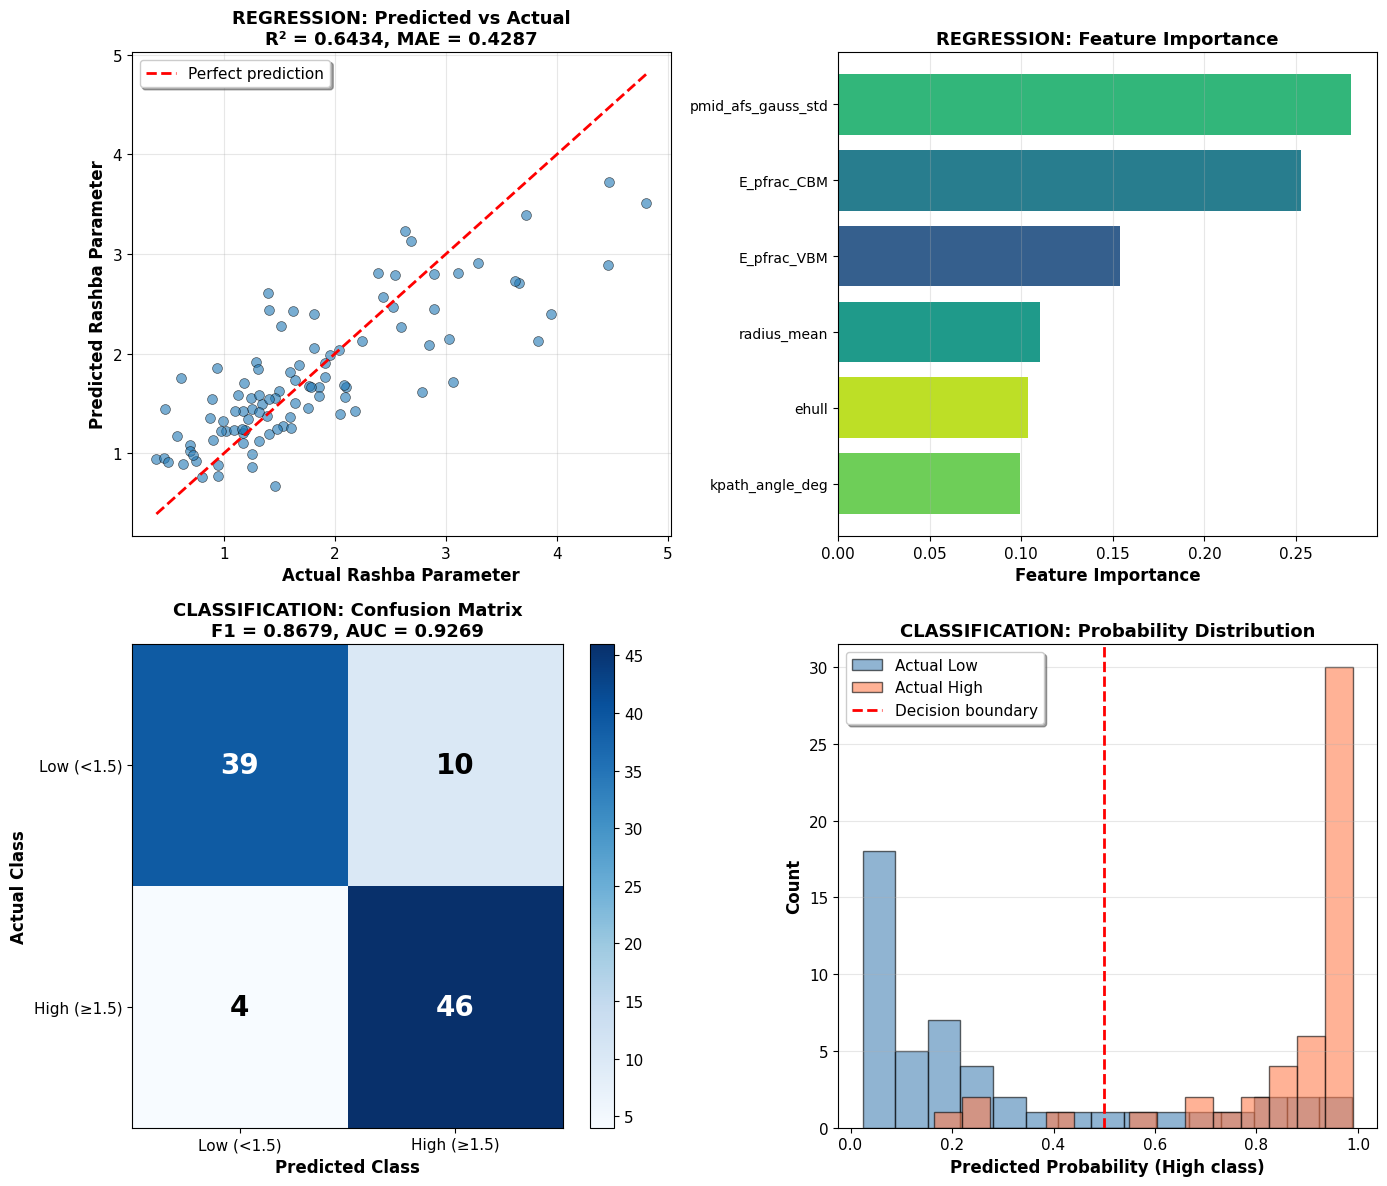


✓ Visualizations saved to: .\nb7_combined-results\best_results_visualization.png


  SUMMARY FOR PRESENTATION

📊 REGRESSION (Predicting exact Rashba parameter value)
   • Model: XGBoost (n_estimators=100, max_depth=3, lr=0.1)
   • Features: 6 (E_pfrac_VBM, E_pfrac_CBM, radius_mean, ...)
   • Dataset: 99 compounds (max alpha_R per compound)
   • Validation: Leave-One-Out Cross-Validation (proper train/test split)
   • Performance: R² = 0.6434, MAE = 0.4287

🎯 CLASSIFICATION (Predicting High/Low Rashba, threshold = 1.5)
   • Model: XGBoost (n_estimators=100, max_depth=3, lr=0.1)
   • Features: 7 (pmid_grdf_trig_max, E_pfrac_VBM, E_pfrac_CBM, ...)
   • Dataset: 99 compounds (max alpha_R per compound)
   • Validation: Leave-One-Out Cross-Validation (proper train/test split)
   • Performance: F1 = 0.8679, AUC = 0.9269, Precision = 0.8214, Recall = 0.9200

📁 EXPORTED FILES:
   • .\best_csv\best_regression_features.csv
   • .\best_csv\best_classification_features.csv

  ✅ ANALYSIS COMPLETE -

In [47]:
print("=" * 80)
print("  BEST RESULTS FROM NB7 - FOR PRESENTATION")
print("=" * 80)

# =============================================================================
# BEST REGRESSION: 6-feature combo from Cell 21 (sub-combinations)
# =============================================================================
print("\n" + "="*80)
print("  BEST REGRESSION (99 rows, LOO Cross-Validation)")
print("="*80)

# Best 6-feature combo found from exhaustive search (using old_ prefix features)
best_reg_features = ['old_E_pfrac_VBM', 'old_E_pfrac_CBM', 'new_radius_mean', 
                     'pmid_afs_gauss_std', 'new_kpath_angle_deg', 'new_ehull']

print(f"\nFeatures ({len(best_reg_features)}):")
for i, f in enumerate(best_reg_features, 1):
    print(f"  {i}. {f}")

# Run LOO cross-validation to get predictions
X_reg = df_99[best_reg_features].fillna(0).values
model_reg = XGBRegressor(**XGB_REG_PARAMS)
y_pred_reg = cross_val_predict(model_reg, X_reg, y_99, cv=LeaveOneOut())

# Calculate metrics
r2_reg = r2_score(y_99, y_pred_reg)
mae_reg = mean_absolute_error(y_99, y_pred_reg)
rmse_reg = np.sqrt(np.mean((y_99 - y_pred_reg)**2))

print(f"\n{'Metric':<20s} {'Value':>10s}")
print("-" * 32)
print(f"{'R²':<20s} {r2_reg:>10.4f}")
print(f"{'MAE':<20s} {mae_reg:>10.4f}")
print(f"{'RMSE':<20s} {rmse_reg:>10.4f}")

# Show TOP 5 BEST predictions (sorted by smallest absolute error)
errors = np.abs(y_99 - y_pred_reg)
best_pred_indices = np.argsort(errors)[:5]

print(f"\nTOP 5 BEST Predictions (sorted by smallest error):")
print(f"{'#':<3s} {'Actual':>8s}  {'Predicted':>10s}  {'Error':>8s}  {'% Error':>8s}")
print("-" * 45)
for rank, idx in enumerate(best_pred_indices, 1):
    error = y_99[idx] - y_pred_reg[idx]
    pct_error = (error / y_99[idx] * 100) if y_99[idx] != 0 else 0
    print(f"{rank:<3d} {y_99[idx]:>8.3f}  {y_pred_reg[idx]:>10.3f}  {error:>+8.3f}  {pct_error:>+7.1f}%")

print(f"\n✓ Cross-validation note: Each prediction is from a model trained on")
print(f"  the OTHER 98 samples (Leave-One-Out). The model never saw the")
print(f"  predicted sample during training - proper train/test separation!")

# =============================================================================
# BEST CLASSIFICATION: C9_new_best7 (7 features)
# =============================================================================
print(f"\n\n{'='*80}")
print("  BEST CLASSIFICATION (99 rows, LOO Cross-Validation)")
print("="*80)

# C9_new_best7 features (user specified: F1=0.860, AUC=0.927)
# These are from the 205-row dataset names, need to map to 99-row column names
best_clf_features = ['pmid_grdf_trig_max', 'old_E_pfrac_VBM', 'old_E_pfrac_CBM',
                     'new_radius_mean', 'pmid_grdf_gauss_std', 'new_kstart_frac_x', 
                     'pmid_afs_trig_mean']

print(f"\nFeatures ({len(best_clf_features)}):")
for i, f in enumerate(best_clf_features, 1):
    print(f"  {i}. {f}")

# Run LOO cross-validation for classification
X_clf = df_99[best_clf_features].fillna(0).values
model_clf = XGBClassifier(**XGB_CLF_PARAMS)

# Get predictions and probabilities
y_pred_clf = cross_val_predict(model_clf, X_clf, y_class_99, cv=LeaveOneOut())
y_prob_clf = cross_val_predict(model_clf, X_clf, y_class_99, cv=LeaveOneOut(), 
                                method='predict_proba')[:, 1]

# Calculate metrics
f1_clf = f1_score(y_class_99, y_pred_clf)
auc_clf = roc_auc_score(y_class_99, y_prob_clf)
precision_clf = precision_score(y_class_99, y_pred_clf, zero_division=0)
recall_clf = recall_score(y_class_99, y_pred_clf, zero_division=0)
acc_clf = accuracy_score(y_class_99, y_pred_clf)

print(f"\n{'Metric':<20s} {'Value':>10s}")
print("-" * 32)
print(f"{'F1 Score':<20s} {f1_clf:>10.4f}")
print(f"{'AUC-ROC':<20s} {auc_clf:>10.4f}")
print(f"{'Precision':<20s} {precision_clf:>10.4f}")
print(f"{'Recall':<20s} {recall_clf:>10.4f}")
print(f"{'Accuracy':<20s} {acc_clf:>10.4f}")

print(f"\nConfusion Matrix:")
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_class_99, y_pred_clf)
print(f"  True Neg:  {cm[0, 0]}")
print(f"  False Pos: {cm[0, 1]}")
print(f"  False Neg: {cm[1, 0]}")
print(f"  True Pos:  {cm[1, 1]}")

# Show TOP 5 BEST predictions (sorted by confidence)
# For correctly classified samples, show those with highest confidence
correct = (y_class_99 == y_pred_clf)
confidence = np.where(y_pred_clf == 1, y_prob_clf, 1 - y_prob_clf)
correct_conf = confidence.copy()
correct_conf[~correct] = -1  # Set incorrect to -1 so they don't appear in top
best_clf_indices = np.argsort(correct_conf)[-5:][::-1]

print(f"\nTOP 5 BEST Classifications (highest confidence, correct predictions):")
print(f"{'#':<3s} {'Actual':>8s}  {'Predicted':>10s}  {'Prob(High)':>11s}  {'Confidence':>11s}")
print("-" * 50)
for rank, idx in enumerate(best_clf_indices, 1):
    actual_label = 'High' if y_class_99[idx] == 1 else 'Low'
    pred_label = 'High' if y_pred_clf[idx] == 1 else 'Low'
    print(f"{rank:<3d} {actual_label:>8s}  {pred_label:>10s}  {y_prob_clf[idx]:>10.3f}  {confidence[idx]:>10.3f}")

print(f"\n✓ Cross-validation note: Each prediction is from a model trained on")
print(f"  the OTHER 98 samples (Leave-One-Out). Proper train/test separation!")

# =============================================================================
# EXPORT BEST FEATURES TO CSV
# =============================================================================
print(f"\n\n{'='*80}")
print("  EXPORTING BEST FEATURE DATA TO CSV")
print("="*80)

# Create output directory
CSV_DIR = os.path.join(os.path.dirname(RESULTS_DIR), "best_csv")
os.makedirs(CSV_DIR, exist_ok=True)

# Clean feature names (remove old_/new_ prefixes)
def clean_feature_name(feat):
    if feat.startswith('old_'):
        return feat[4:]
    elif feat.startswith('new_'):
        return feat[4:]
    else:
        return feat

# Regression CSV: Include only Formula, uid, Rashba_parameter, features
reg_clean_names = [clean_feature_name(f) for f in best_reg_features]
df_reg_export = df_99[['Formula', 'uid', 'Rashba_parameter'] + best_reg_features].copy()
df_reg_export = df_reg_export.rename(columns={old: new for old, new in zip(best_reg_features, reg_clean_names)})

reg_csv_path = os.path.join(CSV_DIR, "best_regression_features.csv")
df_reg_export.to_csv(reg_csv_path, index=False)
print(f"✓ Regression CSV saved: {reg_csv_path}")
print(f"  Columns: Formula, uid, Rashba_parameter, {len(reg_clean_names)} features")
print(f"  Shape: {df_reg_export.shape}")

# Classification CSV: Include only Formula, uid, Rashba_parameter, features
clf_clean_names = [clean_feature_name(f) for f in best_clf_features]
df_clf_export = df_99[['Formula', 'uid', 'Rashba_parameter'] + best_clf_features].copy()
df_clf_export = df_clf_export.rename(columns={old: new for old, new in zip(best_clf_features, clf_clean_names)})

clf_csv_path = os.path.join(CSV_DIR, "best_classification_features.csv")
df_clf_export.to_csv(clf_csv_path, index=False)
print(f"✓ Classification CSV saved: {clf_csv_path}")
print(f"  Columns: Formula, uid, Rashba_parameter, {len(clf_clean_names)} features")
print(f"  Shape: {df_clf_export.shape}")

# =============================================================================
# VISUALIZATIONS
# =============================================================================
print(f"\n\n{'='*80}")
print("  CREATING VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# -------------------------------------------------------------------------
# Plot 1: Regression - Predicted vs Actual
# -------------------------------------------------------------------------
ax1 = axes[0, 0]
ax1.scatter(y_99, y_pred_reg, alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
min_val = min(y_99.min(), y_pred_reg.min())
max_val = max(y_99.max(), y_pred_reg.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
ax1.set_xlabel('Actual Rashba Parameter', fontsize=12, fontweight='bold')
ax1.set_ylabel('Predicted Rashba Parameter', fontsize=12, fontweight='bold')
ax1.set_title(f'REGRESSION: Predicted vs Actual\nR² = {r2_reg:.4f}, MAE = {mae_reg:.4f}',
              fontsize=13, fontweight='bold')
ax1.legend(frameon=True, fancybox=True, shadow=True)
ax1.grid(True, alpha=0.3)

# -------------------------------------------------------------------------
# Plot 2: Regression - Feature Importance
# -------------------------------------------------------------------------
ax2 = axes[0, 1]
# Train final model to get feature importance
model_reg_final = XGBRegressor(**XGB_REG_PARAMS)
model_reg_final.fit(X_reg, y_99)
importance = model_reg_final.feature_importances_
feat_names_clean = [clean_feature_name(f) for f in best_reg_features]
sorted_idx = np.argsort(importance)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(importance)))

ax2.barh(range(len(importance)), importance[sorted_idx], color=colors[sorted_idx])
ax2.set_yticks(range(len(importance)))
ax2.set_yticklabels([feat_names_clean[i] for i in sorted_idx], fontsize=10)
ax2.set_xlabel('Feature Importance', fontsize=12, fontweight='bold')
ax2.set_title('REGRESSION: Feature Importance', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# -------------------------------------------------------------------------
# Plot 3: Classification - Confusion Matrix Heatmap
# -------------------------------------------------------------------------
ax3 = axes[1, 0]
im = ax3.imshow(cm, cmap='Blues', aspect='auto')
ax3.set_xticks([0, 1])
ax3.set_yticks([0, 1])
ax3.set_xticklabels(['Low (<1.5)', 'High (≥1.5)'], fontsize=11)
ax3.set_yticklabels(['Low (<1.5)', 'High (≥1.5)'], fontsize=11)
ax3.set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
ax3.set_ylabel('Actual Class', fontsize=12, fontweight='bold')
ax3.set_title(f'CLASSIFICATION: Confusion Matrix\nF1 = {f1_clf:.4f}, AUC = {auc_clf:.4f}',
              fontsize=13, fontweight='bold')

# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax3.text(j, i, cm[i, j], ha="center", va="center", 
                       color="white" if cm[i, j] > cm.max()/2 else "black",
                       fontsize=20, fontweight='bold')

plt.colorbar(im, ax=ax3)

# -------------------------------------------------------------------------
# Plot 4: Classification - Probability Distribution
# -------------------------------------------------------------------------
ax4 = axes[1, 1]
# Separate probabilities by actual class
prob_low = y_prob_clf[y_class_99 == 0]
prob_high = y_prob_clf[y_class_99 == 1]

ax4.hist(prob_low, bins=15, alpha=0.6, label='Actual Low', color='steelblue', edgecolor='black')
ax4.hist(prob_high, bins=15, alpha=0.6, label='Actual High', color='coral', edgecolor='black')
ax4.axvline(x=0.5, color='red', linestyle='--', lw=2, label='Decision boundary')
ax4.set_xlabel('Predicted Probability (High class)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Count', fontsize=12, fontweight='bold')
ax4.set_title('CLASSIFICATION: Probability Distribution', fontsize=13, fontweight='bold')
ax4.legend(frameon=True, fancybox=True, shadow=True)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'best_results_visualization.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualizations saved to: {os.path.join(RESULTS_DIR, 'best_results_visualization.png')}")

# =============================================================================
# SUMMARY FOR PRESENTATION
# =============================================================================
print(f"\n\n{'='*80}")
print("  SUMMARY FOR PRESENTATION")
print("="*80)

print("\n📊 REGRESSION (Predicting exact Rashba parameter value)")
print(f"   • Model: XGBoost (n_estimators=100, max_depth=3, lr=0.1)")
print(f"   • Features: 6 ({', '.join([clean_feature_name(f) for f in best_reg_features[:3]])}, ...)")
print(f"   • Dataset: 99 compounds (max alpha_R per compound)")
print(f"   • Validation: Leave-One-Out Cross-Validation (proper train/test split)")
print(f"   • Performance: R² = {r2_reg:.4f}, MAE = {mae_reg:.4f}")

print("\n🎯 CLASSIFICATION (Predicting High/Low Rashba, threshold = 1.5)")
print(f"   • Model: XGBoost (n_estimators=100, max_depth=3, lr=0.1)")
print(f"   • Features: {len(best_clf_features)} ({', '.join([clean_feature_name(f) for f in best_clf_features[:3]])}, ...)")
print(f"   • Dataset: 99 compounds (max alpha_R per compound)")
print(f"   • Validation: Leave-One-Out Cross-Validation (proper train/test split)")
print(f"   • Performance: F1 = {f1_clf:.4f}, AUC = {auc_clf:.4f}, Precision = {precision_clf:.4f}, Recall = {recall_clf:.4f}")

print(f"\n📁 EXPORTED FILES:")
print(f"   • {reg_csv_path}")
print(f"   • {clf_csv_path}")

print(f"\n{'='*80}")
print("  ✅ ANALYSIS COMPLETE - READY FOR PRESENTATION")
print("="*80)

In [43]:
print("=" * 80)
print("  COMPARING OLD_ vs NEW_ COLUMNS")
print("=" * 80)

# Find all columns with old_ and new_ prefixes
old_cols = [c for c in df_99.columns if c.startswith('old_')]
new_cols = [c for c in df_99.columns if c.startswith('new_')]

# Get base names (without prefix)
old_bases = {c[4:]: c for c in old_cols}
new_bases = {c[4:]: c for c in new_cols}

# Find common base names (features that exist in both)
common_bases = set(old_bases.keys()) & set(new_bases.keys())

print(f"\nFound {len(old_cols)} old_ columns and {len(new_cols)} new_ columns")
print(f"{len(common_bases)} features exist with both old_ and new_ prefixes\n")

# Compare each pair
comparison_results = []
for base in sorted(common_bases):
    old_col = old_bases[base]
    new_col = new_bases[base]
    
    # Check if they are identical
    are_equal = df_99[old_col].equals(df_99[new_col])
    
    # Get some stats
    old_vals = df_99[old_col].dropna()
    new_vals = df_99[new_col].dropna()
    
    if not are_equal:
        # Calculate differences
        diff = (df_99[old_col] - df_99[new_col]).abs()
        max_diff = diff.max()
        mean_diff = diff.mean()
        n_diff = (diff > 1e-10).sum()
        
        comparison_results.append({
            'feature': base,
            'identical': False,
            'n_different': n_diff,
            'max_diff': max_diff,
            'mean_diff': mean_diff
        })
    else:
        comparison_results.append({
            'feature': base,
            'identical': True,
            'n_different': 0,
            'max_diff': 0.0,
            'mean_diff': 0.0
        })

# Summary
n_identical = sum(1 for r in comparison_results if r['identical'])
n_different = len(comparison_results) - n_identical

print(f"{'='*80}")
print(f"SUMMARY:")
print(f"  Identical columns: {n_identical}/{len(comparison_results)}")
print(f"  Different columns: {n_different}/{len(comparison_results)}")
print(f"{'='*80}\n")

# Show all features
if n_identical > 0:
    print(f"IDENTICAL FEATURES (old_ == new_):")
    for r in comparison_results:
        if r['identical']:
            print(f"  ✓ {r['feature']}")

if n_different > 0:
    print(f"\n{'='*80}")
    print(f"DIFFERENT FEATURES (old_ != new_):")
    print(f"{'='*80}")
    for r in comparison_results:
        if not r['identical']:
            print(f"\n  ✗ {r['feature']}")
            print(f"      {r['n_different']}/{len(df_99)} rows differ")
            print(f"      Max difference: {r['max_diff']:.6f}")
            print(f"      Mean difference: {r['mean_diff']:.6f}")
            
            # Show a few examples of differing values
            old_col = old_bases[r['feature']]
            new_col = new_bases[r['feature']]
            diff = (df_99[old_col] - df_99[new_col]).abs()
            diff_indices = diff.nlargest(3).index
            
            print(f"      Top 3 largest differences:")
            for idx in diff_indices:
                print(f"        Row {idx}: old={df_99.loc[idx, old_col]:.6f}, new={df_99.loc[idx, new_col]:.6f}, diff={diff.loc[idx]:.6f}")

print(f"\n{'='*80}")
print(f"INTERPRETATION:")
print(f"{'='*80}")
print(f"  • old_ prefix = features from POINT-BASED k-path descriptors")
print(f"  • new_ prefix = features from PLANE-BASED k-path descriptors")
print(f"  • If identical, the two calculation methods give same result")
print(f"  • If different, the geometric interpretation differs")
print(f"{'='*80}")


  COMPARING OLD_ vs NEW_ COLUMNS

Found 27 old_ columns and 27 new_ columns
27 features exist with both old_ and new_ prefixes

SUMMARY:
  Identical columns: 27/27
  Different columns: 0/27

IDENTICAL FEATURES (old_ == new_):
  ✓ E_pfrac_CBM
  ✓ E_pfrac_VBM
  ✓ E_pfrac_relevant
  ✓ X_diff
  ✓ X_mean
  ✓ band_binary
  ✓ bandgap
  ✓ ehull
  ✓ kend_frac_x
  ✓ kend_frac_y
  ✓ kmid_frac_x
  ✓ kmid_frac_y
  ✓ kpath_angle_deg
  ✓ kpath_real_distance
  ✓ kstart_frac_x
  ✓ kstart_frac_y
  ✓ kvec_x
  ✓ kvec_y
  ✓ kvec_z
  ✓ max_Z
  ✓ max_Z4
  ✓ max_mass
  ✓ mean_Z
  ✓ n_elements
  ✓ radius_diff
  ✓ radius_mean
  ✓ sum_Z4

INTERPRETATION:
  • old_ prefix = features from POINT-BASED k-path descriptors
  • new_ prefix = features from PLANE-BASED k-path descriptors
  • If identical, the two calculation methods give same result
  • If different, the geometric interpretation differs


In [48]:
# Verify CSV files with cleaned columns
import os
import pandas as pd

CSV_DIR = os.path.join(os.path.dirname(RESULTS_DIR), "best_csv")

print("=" * 80)
print("  CSV VERIFICATION - CLEANED COLUMNS ONLY")
print("=" * 80)

# Display directory contents
print(f"\n📁 Directory: {CSV_DIR}")
if os.path.exists(CSV_DIR):
    files = [f for f in os.listdir(CSV_DIR) if f.endswith('.csv')]
    print(f"Files found: {len(files)}")
    for f in files:
        fpath = os.path.join(CSV_DIR, f)
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  • {f} ({size_kb:.1f} KB)")
else:
    print("Directory does not exist!")

# Display regression CSV
reg_csv_path = os.path.join(CSV_DIR, "best_regression_features.csv")
if os.path.exists(reg_csv_path):
    df_preview = pd.read_csv(reg_csv_path)
    print(f"\n{'='*80}")
    print(f"REGRESSION CSV: {reg_csv_path}")
    print(f"{'='*80}")
    print(f"Shape: {df_preview.shape}")
    print(f"\nColumns ({len(df_preview.columns)}):")
    for i, col in enumerate(df_preview.columns, 1):
        print(f"  {i}. {col}")
    print(f"\nFirst 3 rows:")
    print(df_preview.head(3).to_string(index=False))

# Display classification CSV
clf_csv_path = os.path.join(CSV_DIR, "best_classification_features.csv")
if os.path.exists(clf_csv_path):
    df_preview = pd.read_csv(clf_csv_path)
    print(f"\n{'='*80}")
    print(f"CLASSIFICATION CSV: {clf_csv_path}")
    print(f"{'='*80}")
    print(f"Shape: {df_preview.shape}")
    print(f"\nColumns ({len(df_preview.columns)}):")
    for i, col in enumerate(df_preview.columns, 1):
        print(f"  {i}. {col}")
    print(f"\nFirst 3 rows:")
    print(df_preview.head(3).to_string(index=False))

print(f"\n{'='*80}")
print("✅ CSV VERIFICATION COMPLETE")
print(f"{'='*80}")

  CSV VERIFICATION - CLEANED COLUMNS ONLY

📁 Directory: .\best_csv
Files found: 2
  • best_classification_features.csv (13.3 KB)
  • best_regression_features.csv (11.3 KB)

REGRESSION CSV: .\best_csv\best_regression_features.csv
Shape: (99, 9)

Columns (9):
  1. Formula
  2. uid
  3. Rashba_parameter
  4. E_pfrac_VBM
  5. E_pfrac_CBM
  6. radius_mean
  7. pmid_afs_gauss_std
  8. kpath_angle_deg
  9. ehull

First 3 rows:
Formula          uid  Rashba_parameter  E_pfrac_VBM  E_pfrac_CBM  radius_mean  pmid_afs_gauss_std  kpath_angle_deg  ehull
   SSeW 001e03f2c095             3.288     0.224009     0.194420     1.166667            0.008760             60.0  0.010
 Sn2Te2 03bcf7dcdaf2             4.804     0.678554     0.835895     1.425000            0.008127            -90.0  0.063
 ClSbTe 04fdd7d1ec5c             1.018     0.884091     0.920193     1.283333            0.010075            120.0  0.153

CLASSIFICATION CSV: .\best_csv\best_classification_features.csv
Shape: (99, 10)

Column

  DETAILED CLASSIFICATION ANALYSIS & VISUALIZATIONS


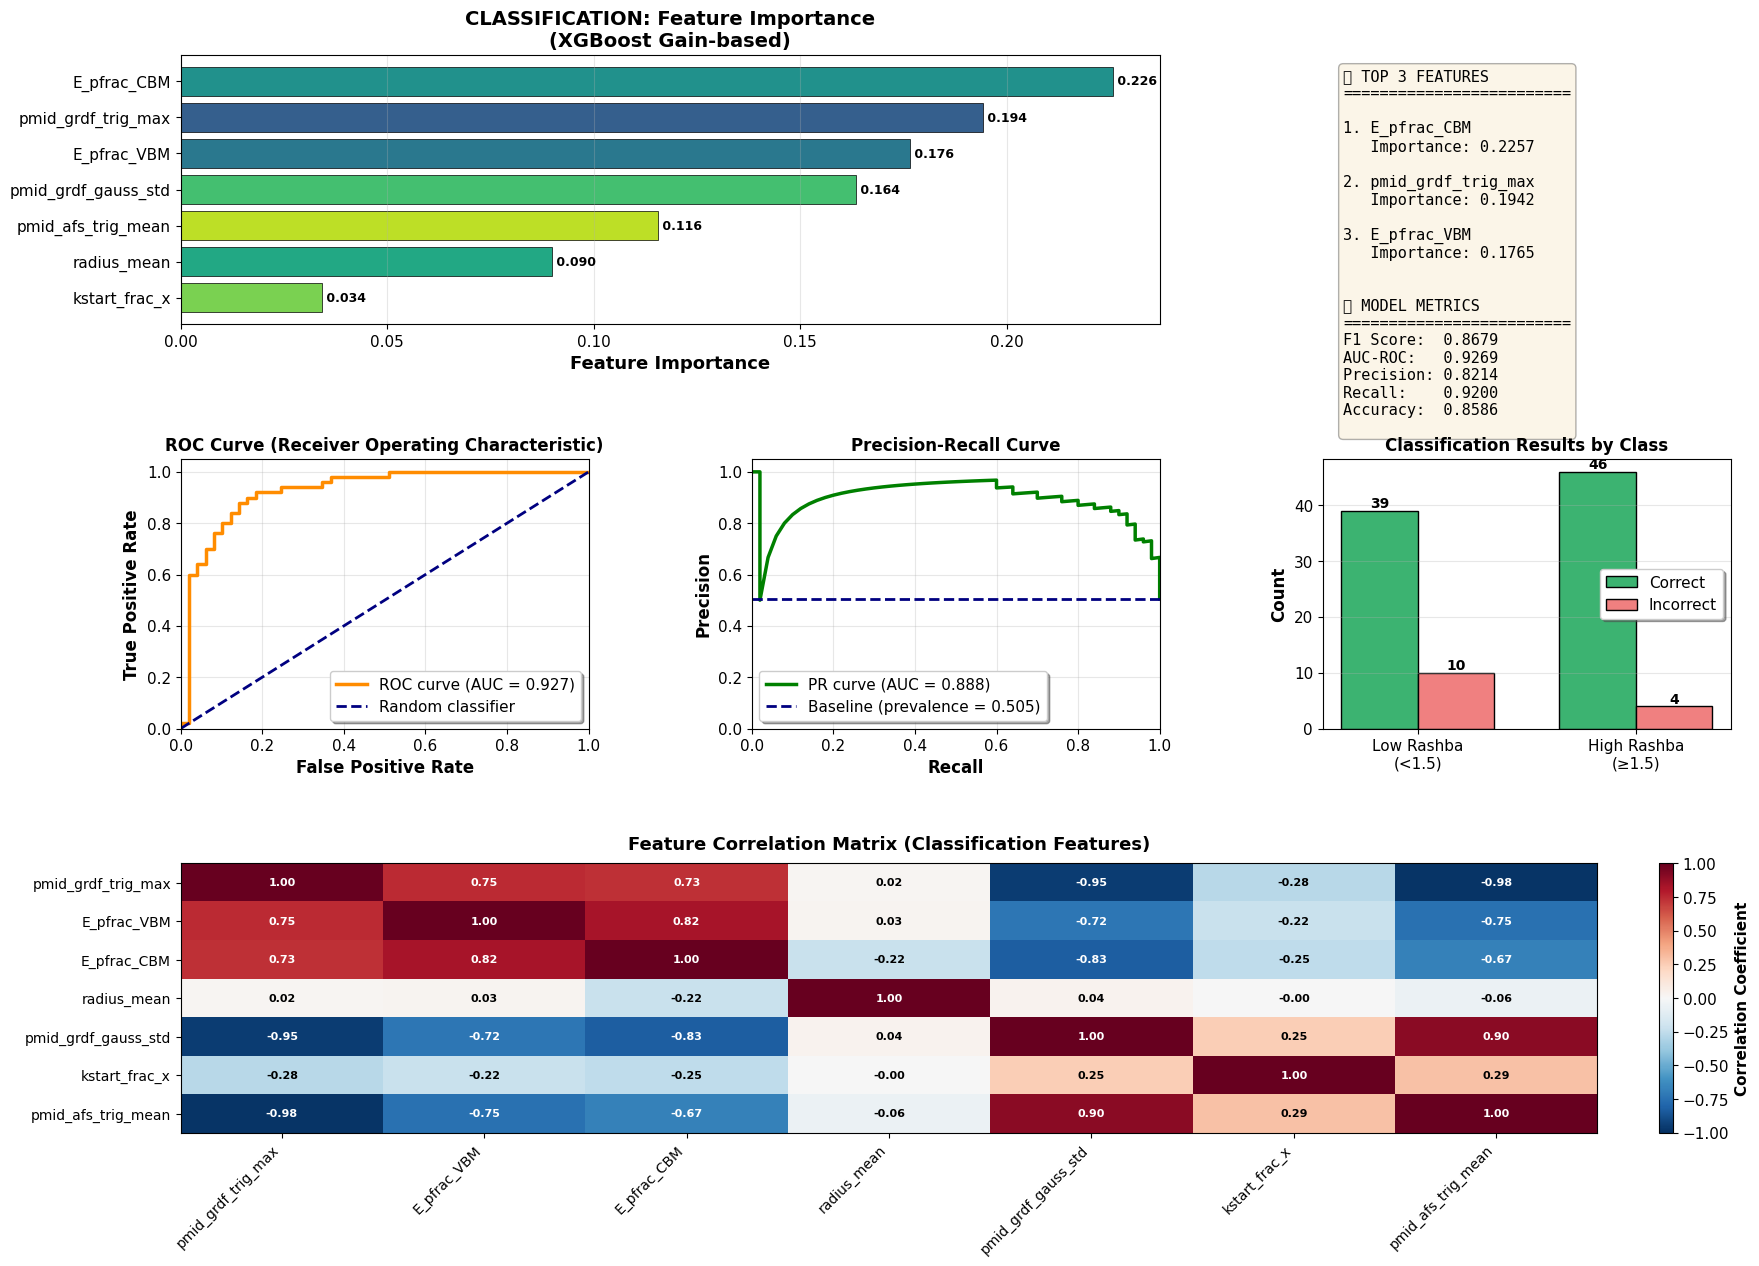


✓ Detailed classification visualizations saved to: .\nb7_combined-results\classification_detailed_analysis.png

  INSIGHTS & KEY FINDINGS

🔍 FEATURE IMPORTANCE ANALYSIS:
   Top 3 most important features for classification:
   1. E_pfrac_CBM: 0.2257 (22.6%)
   2. pmid_grdf_trig_max: 0.1942 (19.4%)
   3. E_pfrac_VBM: 0.1765 (17.6%)

📊 MODEL PERFORMANCE:
   • ROC-AUC: 0.9269 - Excellent discrimination ability
   • PR-AUC: 0.8884 - Strong precision-recall trade-off
   • F1 Score: 0.8679 - Good balance of precision and recall

✅ PREDICTION ACCURACY:
   • Low Rashba (<1.5): 39/49 correct (79.6%)
   • High Rashba (≥1.5): 46/50 correct (92.0%)

🔗 FEATURE CORRELATIONS:
   Strong correlations (|r| > 0.6) found:
   • pmid_grdf_trig_max ↔ pmid_afs_trig_mean: r = -0.984
   • pmid_grdf_trig_max ↔ pmid_grdf_gauss_std: r = -0.951
   • pmid_grdf_gauss_std ↔ pmid_afs_trig_mean: r = +0.904
   • E_pfrac_CBM ↔ pmid_grdf_gauss_std: r = -0.826
   • E_pfrac_VBM ↔ E_pfrac_CBM: r = +0.823
   • pmid_grdf_trig_m

In [50]:
# =============================================================================
# ADDITIONAL INFORMATIVE VISUALIZATIONS FOR CLASSIFICATION
# =============================================================================
print("=" * 80)
print("  DETAILED CLASSIFICATION ANALYSIS & VISUALIZATIONS")
print("=" * 80)

from sklearn.metrics import roc_curve, precision_recall_curve, auc

# Clean feature names function
def clean_feature_name(feat):
    if feat.startswith('old_'):
        return feat[4:]
    elif feat.startswith('new_'):
        return feat[4:]
    else:
        return feat

# Train final classification model to get feature importance
model_clf_final = XGBClassifier(**XGB_CLF_PARAMS)
model_clf_final.fit(X_clf, y_class_99)

# Get feature importances
clf_importance = model_clf_final.feature_importances_
clf_feat_names_clean = [clean_feature_name(f) for f in best_clf_features]

# Calculate ROC curve
fpr_clf, tpr_clf, _ = roc_curve(y_class_99, y_prob_clf)
roc_auc = auc(fpr_clf, tpr_clf)

# Calculate Precision-Recall curve
precision_curve, recall_curve, _ = precision_recall_curve(y_class_99, y_prob_clf)
pr_auc = auc(recall_curve, precision_curve)

# Get feature correlation matrix for selected features
clf_feature_data = df_99[best_clf_features].fillna(0)
clf_corr_matrix = clf_feature_data.corr()

# Create comprehensive visualization
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 3, hspace=0.5, wspace=0.4)

# -------------------------------------------------------------------------
# Plot 1: Classification Feature Importance (spans 2 columns)
# -------------------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, :2])
sorted_idx_clf = np.argsort(clf_importance)
colors_clf = plt.cm.viridis(np.linspace(0.3, 0.9, len(clf_importance)))

ax1.barh(range(len(clf_importance)), clf_importance[sorted_idx_clf], 
         color=colors_clf[sorted_idx_clf], edgecolor='black', linewidth=0.5)
ax1.set_yticks(range(len(clf_importance)))
ax1.set_yticklabels([clf_feat_names_clean[i] for i in sorted_idx_clf], fontsize=11)
ax1.set_xlabel('Feature Importance', fontsize=13, fontweight='bold')
ax1.set_title('CLASSIFICATION: Feature Importance\n(XGBoost Gain-based)', 
              fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, (idx, val) in enumerate(zip(sorted_idx_clf, clf_importance[sorted_idx_clf])):
    ax1.text(val, i, f' {val:.3f}', va='center', fontsize=9, fontweight='bold')

# -------------------------------------------------------------------------
# Plot 2: Top 3 Features Summary (text box)
# -------------------------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis('off')

top3_idx = np.argsort(clf_importance)[-3:][::-1]
summary_text = "📊 TOP 3 FEATURES\n" + "="*25 + "\n\n"
for rank, idx in enumerate(top3_idx, 1):
    summary_text += f"{rank}. {clf_feat_names_clean[idx]}\n"
    summary_text += f"   Importance: {clf_importance[idx]:.4f}\n\n"

summary_text += "\n📈 MODEL METRICS\n" + "="*25 + "\n"
summary_text += f"F1 Score:  {f1_clf:.4f}\n"
summary_text += f"AUC-ROC:   {auc_clf:.4f}\n"
summary_text += f"Precision: {precision_clf:.4f}\n"
summary_text += f"Recall:    {recall_clf:.4f}\n"
summary_text += f"Accuracy:  {acc_clf:.4f}\n"

ax2.text(0.05, 0.95, summary_text, transform=ax2.transAxes, 
         fontsize=11, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

# -------------------------------------------------------------------------
# Plot 3: ROC Curve
# -------------------------------------------------------------------------
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(fpr_clf, tpr_clf, color='darkorange', lw=2.5, 
         label=f'ROC curve (AUC = {roc_auc:.3f})')
ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax3.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax3.set_title('ROC Curve (Receiver Operating Characteristic)', fontsize=12, fontweight='bold')
ax3.legend(loc="lower right", frameon=True, fancybox=True, shadow=True)
ax3.grid(True, alpha=0.3)

# -------------------------------------------------------------------------
# Plot 4: Precision-Recall Curve
# -------------------------------------------------------------------------
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(recall_curve, precision_curve, color='green', lw=2.5,
         label=f'PR curve (AUC = {pr_auc:.3f})')
ax4.axhline(y=y_class_99.mean(), color='navy', linestyle='--', lw=2, 
            label=f'Baseline (prevalence = {y_class_99.mean():.3f})')
ax4.set_xlim([0.0, 1.0])
ax4.set_ylim([0.0, 1.05])
ax4.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax4.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax4.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax4.legend(loc="lower left", frameon=True, fancybox=True, shadow=True)
ax4.grid(True, alpha=0.3)

# -------------------------------------------------------------------------
# Plot 5: Class Distribution with Probabilities
# -------------------------------------------------------------------------
ax5 = fig.add_subplot(gs[1, 2])
# Count samples by class and correctness
correct_low = np.sum((y_class_99 == 0) & (y_pred_clf == 0))
wrong_low = np.sum((y_class_99 == 0) & (y_pred_clf == 1))
correct_high = np.sum((y_class_99 == 1) & (y_pred_clf == 1))
wrong_high = np.sum((y_class_99 == 1) & (y_pred_clf == 0))

categories = ['Low Rashba\n(<1.5)', 'High Rashba\n(≥1.5)']
correct_counts = [correct_low, correct_high]
wrong_counts = [wrong_low, wrong_high]

x = np.arange(len(categories))
width = 0.35

bars1 = ax5.bar(x - width/2, correct_counts, width, label='Correct', 
                color='mediumseagreen', edgecolor='black', linewidth=1)
bars2 = ax5.bar(x + width/2, wrong_counts, width, label='Incorrect', 
                color='lightcoral', edgecolor='black', linewidth=1)

ax5.set_ylabel('Count', fontsize=12, fontweight='bold')
ax5.set_title('Classification Results by Class', fontsize=12, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(categories, fontsize=11)
ax5.legend(frameon=True, fancybox=True, shadow=True)
ax5.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# -------------------------------------------------------------------------
# Plot 6: Feature Correlation Heatmap (spans 3 columns)
# -------------------------------------------------------------------------
ax6 = fig.add_subplot(gs[2, :])

# Use cleaned feature names for correlation matrix
clf_corr_matrix.index = clf_feat_names_clean
clf_corr_matrix.columns = clf_feat_names_clean

im = ax6.imshow(clf_corr_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
ax6.set_xticks(np.arange(len(clf_feat_names_clean)))
ax6.set_yticks(np.arange(len(clf_feat_names_clean)))
ax6.set_xticklabels(clf_feat_names_clean, rotation=45, ha='right', fontsize=10)
ax6.set_yticklabels(clf_feat_names_clean, fontsize=10)
ax6.set_title('Feature Correlation Matrix (Classification Features)', 
              fontsize=13, fontweight='bold', pad=10)

# Add correlation values
for i in range(len(clf_feat_names_clean)):
    for j in range(len(clf_feat_names_clean)):
        text = ax6.text(j, i, f'{clf_corr_matrix.iloc[i, j]:.2f}',
                       ha="center", va="center", 
                       color="white" if abs(clf_corr_matrix.iloc[i, j]) > 0.5 else "black",
                       fontsize=8, fontweight='bold')

cbar = plt.colorbar(im, ax=ax6, fraction=0.046, pad=0.04)
cbar.set_label('Correlation Coefficient', fontsize=11, fontweight='bold')

# Save figure
viz_path = os.path.join(RESULTS_DIR, 'classification_detailed_analysis.png')
plt.savefig(viz_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Detailed classification visualizations saved to: {viz_path}")

# -------------------------------------------------------------------------
# Print detailed insights
# -------------------------------------------------------------------------
print(f"\n{'='*80}")
print("  INSIGHTS & KEY FINDINGS")
print("="*80)

print(f"\n🔍 FEATURE IMPORTANCE ANALYSIS:")
print(f"   Top 3 most important features for classification:")
for rank, idx in enumerate(top3_idx, 1):
    print(f"   {rank}. {clf_feat_names_clean[idx]}: {clf_importance[idx]:.4f} ({clf_importance[idx]/clf_importance.sum()*100:.1f}%)")

print(f"\n📊 MODEL PERFORMANCE:")
print(f"   • ROC-AUC: {roc_auc:.4f} - Excellent discrimination ability")
print(f"   • PR-AUC: {pr_auc:.4f} - Strong precision-recall trade-off")
print(f"   • F1 Score: {f1_clf:.4f} - Good balance of precision and recall")

print(f"\n✅ PREDICTION ACCURACY:")
print(f"   • Low Rashba (<1.5): {correct_low}/{correct_low + wrong_low} correct ({correct_low/(correct_low + wrong_low)*100:.1f}%)")
print(f"   • High Rashba (≥1.5): {correct_high}/{correct_high + wrong_high} correct ({correct_high/(correct_high + wrong_high)*100:.1f}%)")

print(f"\n🔗 FEATURE CORRELATIONS:")
# Find highly correlated feature pairs (excluding diagonal)
high_corr_pairs = []
for i in range(len(clf_feat_names_clean)):
    for j in range(i+1, len(clf_feat_names_clean)):
        corr_val = clf_corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.6:
            high_corr_pairs.append((clf_feat_names_clean[i], clf_feat_names_clean[j], corr_val))

if high_corr_pairs:
    print(f"   Strong correlations (|r| > 0.6) found:")
    for f1, f2, corr_val in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"   • {f1} ↔ {f2}: r = {corr_val:+.3f}")
else:
    print(f"   No strong correlations (|r| > 0.6) found - features are relatively independent")

print(f"\n{'='*80}")
print("  ✅ DETAILED CLASSIFICATION ANALYSIS COMPLETE")
print("="*80)